In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
import math
warnings.filterwarnings('ignore')

In [2]:
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei', 'STHeiti']
plt.rcParams['axes.unicode_minus'] = False
sns.set(style='whitegrid', font_scale=1.1)

from pathlib import Path

BASE_DIR = str(Path().resolve().parent)
OUTPUT_DIR = os.path.join(BASE_DIR, 'exploratory data analysis', 'analysis_output', 'lpl_2026_split2')
os.makedirs(OUTPUT_DIR, exist_ok=True)

## Data Loading

In [7]:
print("=" * 60)
print("LPL 2026 Split 2 Analysis")
print("=" * 60)
target_league = 'LPL'

cs = pd.read_csv(os.path.join(BASE_DIR, 'cleaned_data/champion_season_stats_cleaned.csv'), encoding='utf-8-sig')
synergy = pd.read_csv(os.path.join(BASE_DIR, 'cleaned_data/champion_synergy_cleaned.csv'), encoding='utf-8-sig')
counters = pd.read_csv(os.path.join(BASE_DIR, 'cleaned_data/champion_counters_cleaned.csv'), encoding='utf-8-sig')
matches = pd.read_csv(os.path.join(BASE_DIR, 'cleaned_data/matches_cleaned.csv'), encoding='utf-8-sig')
ranks = pd.read_csv(os.path.join(BASE_DIR, 'cleaned_data/champion_ranks_cleaned.csv'), encoding='utf-8-sig')

matches['date'] = pd.to_datetime(matches['date'], errors='coerce')

cs_s2_raw = cs[cs['season'] == '2026 Split 2'].copy()
cs_s1_raw = cs[cs['season'] == '2026 Split 1'].copy()

# =============================================================================
# Aggregate champion_season_stats across groups (same champion+position
# may have multiple rows from different groups like Group Ascend / Nirvana).
# Strategy:
#   - SUM: picks, bans, wins, losses, kills, deaths, assists, 1ST_B, 1ST_T
#   - WEIGHTED_AVG (by picks): KDA, DPM, DTPM, GPM, CSPM, DPGR
#   - RECALCULATE: win_rate, picks_rate, bans_rate, presence
#   - KEEP FIRST: season, league
# =============================================================================
def aggregate_champion_stats(df):
    if df.empty:
        return df
    
    # Fix: Use exact column names from schema (e.g., KDA instead of kda)
    sum_cols = ['picks', 'bans', 'wins', 'losses', 'kills', 'deaths', 'assists']
    sum_cols_present = [c for c in sum_cols if c in df.columns]
    
    wavg_cols = ['KDA', 'dpm', 'dtpm', 'gpm', 'cspm'] 
    wavg_cols_present = [c for c in wavg_cols if c in df.columns]
    
    first_cols = ['season']
    first_cols_present = [c for c in first_cols if c in df.columns]

    agg_dict = {}
    for c in sum_cols_present:
        agg_dict[c] = 'sum'
    for c in wavg_cols_present:
        # Keep your weighted average safeguard
        agg_dict[c] = lambda x: np.average(x, weights=df.loc[x.index, 'picks']) if df.loc[x.index, 'picks'].sum() > 0 else np.nan
    for c in first_cols_present:
        agg_dict[c] = 'first'
        
    if '1ST_B' in df.columns:
        agg_dict['1ST_B'] = 'sum'
    if '1ST_T' in df.columns:
        agg_dict['1ST_T'] = 'sum'
    if 'DPGR' in df.columns:
        agg_dict['DPGR'] = lambda x: np.average(x, weights=df.loc[x.index, 'picks']) if df.loc[x.index, 'picks'].sum() > 0 else np.nan

    # Exclude 'presence' from agg_dict because we will recalculate it
    grouped = df.groupby(['champion', 'position']).agg(agg_dict).reset_index()

    # Total games estimation using picks is mathematically sound since total picks across all champs = games * 10
    total_games = math.ceil(grouped['picks'].sum() / 10) if grouped['picks'].sum() > 0 else 1
    
    # Recalculate rates
    grouped['win_rate'] = grouped['wins'] / grouped['picks'].replace(0, np.nan)
    grouped['picks_rate'] = grouped['picks'] / total_games
    grouped['bans_rate'] = grouped['bans'] / total_games
    
    # Fix: Recalculate presence based on total_games
    grouped['presence'] = (grouped['picks'] + grouped['bans']) / total_games
    
    return grouped

cs_s2 = aggregate_champion_stats(cs_s2_raw)
cs_s1 = aggregate_champion_stats(cs_s1_raw)


# Validation: check no duplicate champion+position
dup_check = cs_s2.duplicated(subset=['champion', 'position'], keep=False)
if dup_check.any():
    print(f"WARNING: {dup_check.sum()} duplicate champion+position rows found after aggregation!")
else:
    print(f"Validation passed: no duplicate champion+position in cs_s2 ({len(cs_s2)} rows, {cs_s2['champion'].nunique()} unique champions)")

matches_s2 = matches[matches['split'] == 'Split 2'].copy() 
matches_s1 = matches[matches['split'] == 'Split 1'].copy()

# Build teams_s2 from flattened matches (one row per team per game)
POS_KEYS = {'top': 'top', 'jng': 'jungle', 'mid': 'mid', 'bot': 'bot', 'sup': 'support'}
team_rows = []
player_rows = []
for _, row in matches_s2.iterrows():
    for side in ['blue', 'red']:
        side_label = side.capitalize()
        team_result = row['result'] if side == 'blue' else (1 - row['result'])
        tr = {'gameid': row['gameid'], 'date': row['date'], 'side': side_label, 'result': team_result}
        for i in range(1, 6):
            tr[f'ban{i}'] = row.get(f'{side}_ban{i}', None)
            tr[f'pick{i}'] = row.get(f'{side}_pick{i}', None)
        team_rows.append(tr)
        for pos_key, pos_full in POS_KEYS.items():
            champ = row.get(f'{side}_{pos_key}_champion', None)
            if pd.notna(champ) and str(champ) not in ['', 'Unknown']:
                player_rows.append({
                    'gameid': row['gameid'], 'date': row['date'],
                    'side': side_label, 'position': pos_full, 'champion': champ
                })
teams_s2 = pd.DataFrame(team_rows)
players_s2 = pd.DataFrame(player_rows)



print(f"Champion Season 2026 Split 2: {len(cs_s2)} rows, {cs_s2['champion'].nunique()} champions")
print(f"Matches 2026 Split 2: {matches_s2['gameid'].nunique()} games")
print(f"Matches 2026 Split 1: {matches_s1['gameid'].nunique()} games")
print(f"Synergy: {len(synergy)} rows")
print(f"Counters: {len(counters)} rows")
print(f"Ranks: {len(ranks)} rows")
print(f"Matches 2026 Split 2: {matches_s2['gameid'].nunique()} games")
print((len(players_s2)))

LPL 2026 Split 2 Analysis
Validation passed: no duplicate champion+position in cs_s2 (115 rows, 98 unique champions)
Champion Season 2026 Split 2: 115 rows, 98 champions
Matches 2026 Split 2: 1347 games
Matches 2026 Split 1: 1372 games
Synergy: 1986 rows
Counters: 5212 rows
Ranks: 252 rows
Matches 2026 Split 2: 1347 games
13470


## Analysis 1: Hot champions - Presence, Win Rate and Ban Rate


Top 20 英雄 (按总出场数):
 champion  total_picks  total_bans  total_games  win_rate
    Varus           21         161          182  0.571429
  Ambessa           32          72          104  0.656250
    Karma           18          84          102  0.333333
   Rumble           27          74          101  0.444444
  Orianna           10          81           91  0.600000
Jarvan IV           41          47           88  0.463415
 Nocturne           28          58           86  0.571429
     Ryze           35          46           81  0.600000
     Ashe           32          46           78  0.687500
     Bard           37          38           75  0.594595
 Pantheon           41          33           74  0.463415
       Vi           27          44           71  0.703704
   Aurora           30          35           65  0.433333
 Xin Zhao           43          18           61  0.372093
   Lucian           29          29           58  0.551724
     Lulu           37          21           58  0.4

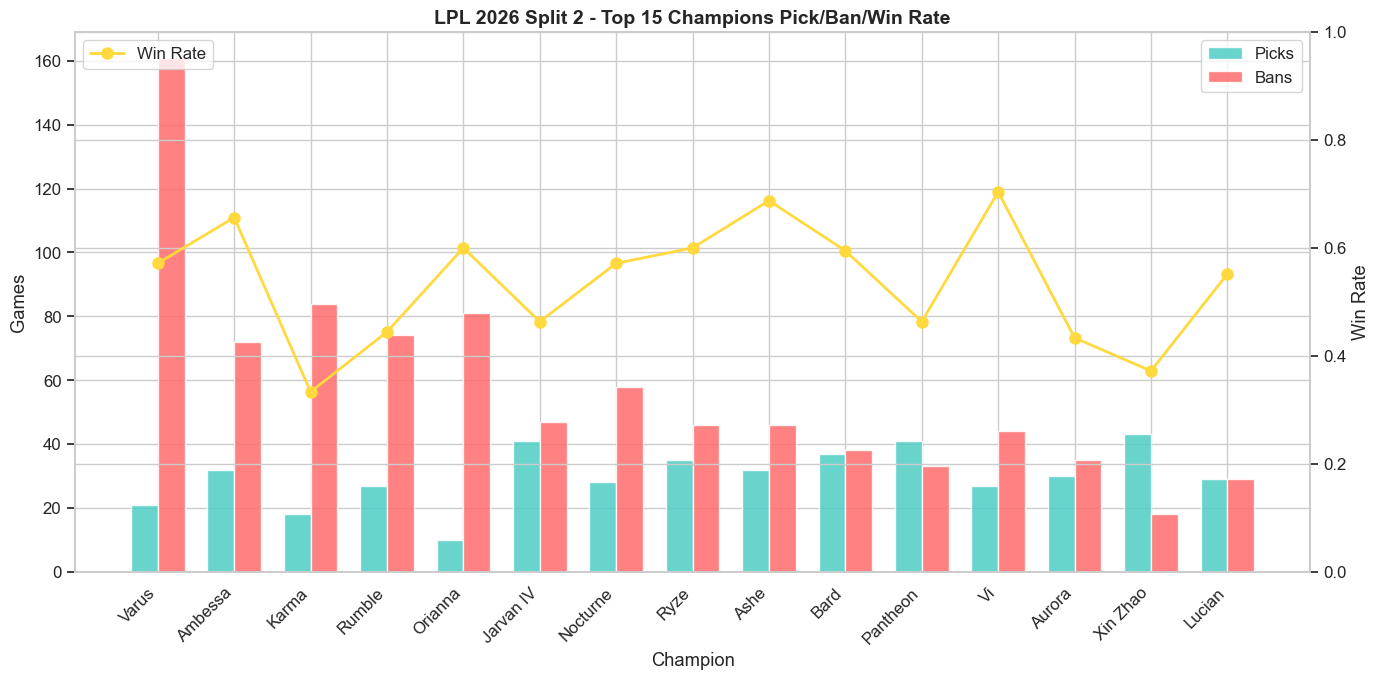

Chart saved: 1a_top_champions_pick_ban_winrate.png


In [ ]:
top15 = presence.head(15).copy()
fig, ax1 = plt.subplots(figsize=(14, 7))
x = np.arange(len(top15))
width = 0.35

bars1 = ax1.bar(x - width/2, top15['total_picks'], width, label='Picks', color='#4ECDC4', alpha=0.85)
bars2 = ax1.bar(x + width/2, top15['total_bans'], width, label='Bans', color='#FF6B6B', alpha=0.85)

ax1.set_xlabel('Champion')
ax1.set_ylabel('Games')
ax1.set_xticks(x)
ax1.set_xticklabels(top15['champion'], rotation=45, ha='right')
ax1.legend(loc='upper right')

ax2 = ax1.twinx()
ax2.plot(x, top15['win_rate'], 'o-', color='#FFD93D', linewidth=2, markersize=8, label='Win Rate')
ax2.set_ylabel('Win Rate')
ax2.set_ylim(0, 1)
ax2.legend(loc='upper left')

# 2. 标题动态化
plt.title(f'{target_league} 2026 Split 2 - Top 15 Champions Pick/Ban/Win Rate', fontsize=14, fontweight='bold')
plt.tight_layout()

# 3. 修复 BUG：必须先 savefig，再 show！
# 文件名也加入了目标联赛的变量，防止覆盖其他联赛的图表
file_name = f'1a_{target_league.lower()}_top_champions_pick_ban_winrate.png'
plt.savefig(os.path.join(OUTPUT_DIR, file_name), dpi=150)
plt.show() 
plt.close()

print(f"Chart saved: {file_name}")

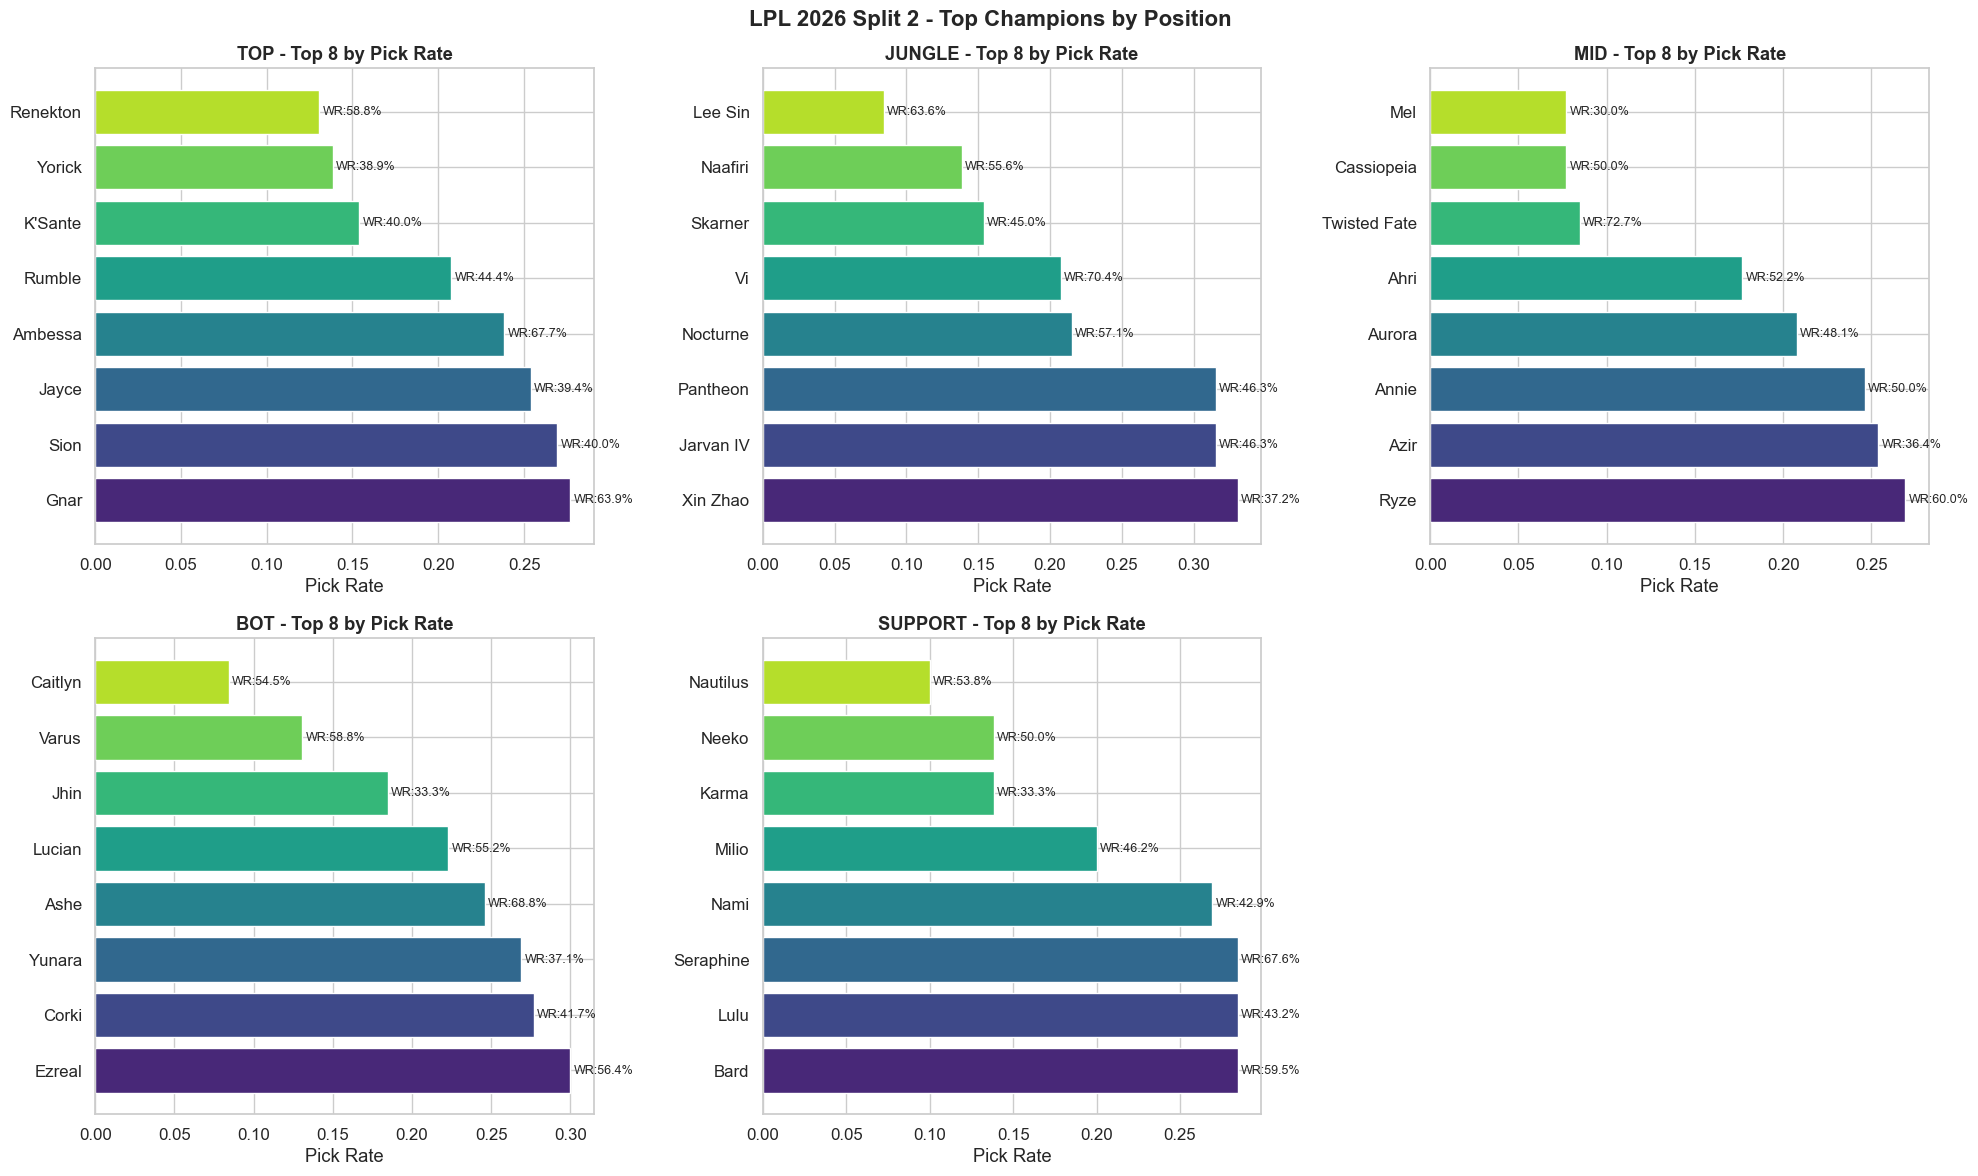

Chart saved: 1b_position_top_champions.png


In [20]:
# 1b: By position - Top champions
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
positions = ['top', 'jungle', 'mid', 'bot', 'support']
for idx, pos in enumerate(positions):
    ax = axes[idx // 3][idx % 3]
    pos_data = cs_s2[cs_s2['position'] == pos].nlargest(8, 'picks_rate')
    if pos_data.empty:
        ax.set_title(f'{pos} - No Data')
        continue
    bars = ax.barh(pos_data['champion'], pos_data['picks_rate'], color=sns.color_palette('viridis', len(pos_data)))
    ax.set_title(f'{pos.upper()} - Top 8 by Pick Rate', fontweight='bold')
    ax.set_xlabel('Pick Rate')
    for bar, wr in zip(bars, pos_data['win_rate']):
        ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2, f'WR:{wr:.1%}', va='center', fontsize=9)
axes[1][2].axis('off')
plt.suptitle('LPL 2026 Split 2 - Top Champions by Position', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()
plt.savefig(os.path.join(OUTPUT_DIR, '1b_position_top_champions.png'), dpi=150)
plt.close()
print("Chart saved: 1b_position_top_champions.png")

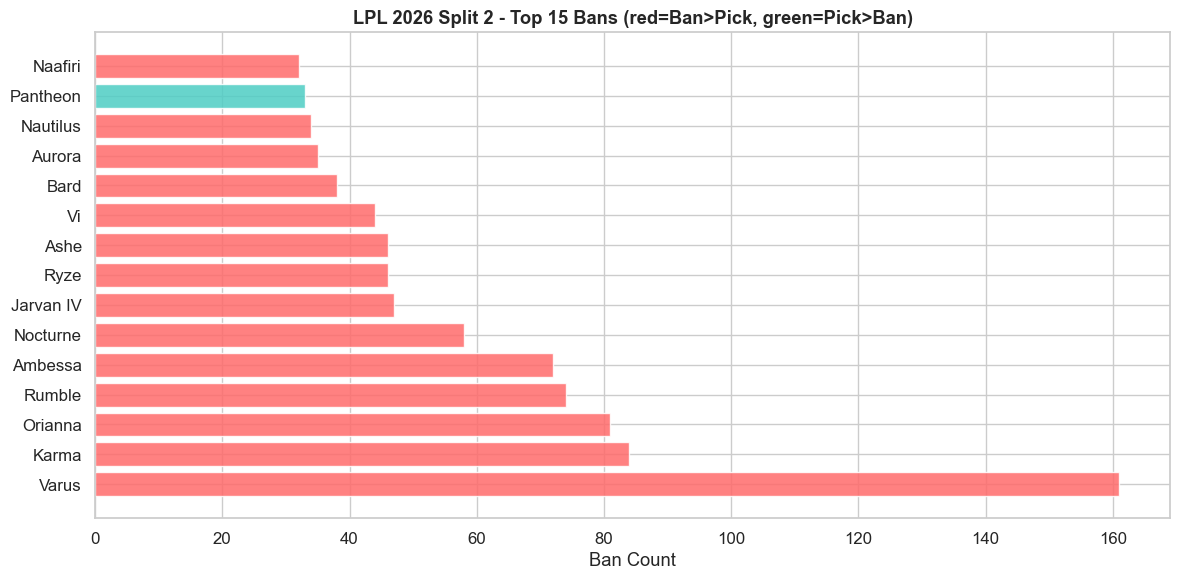

Chart saved: 1c_top_banned_champions.png


In [21]:
# 1c: Ban rate analysis
ban_top = presence.nlargest(15, 'total_bans')
fig, ax = plt.subplots(figsize=(12, 6))
colors = ['#FF6B6B' if b > p else '#4ECDC4' for b, p in zip(ban_top['total_bans'], ban_top['total_picks'])]
ax.barh(ban_top['champion'], ban_top['total_bans'], color=colors, alpha=0.85)
ax.set_xlabel('Ban Count')
ax.set_title('LPL 2026 Split 2 - Top 15 Bans (red=Ban>Pick, green=Pick>Ban)', fontweight='bold')
plt.tight_layout()
plt.show()
plt.savefig(os.path.join(OUTPUT_DIR, '1c_top_banned_champions.png'), dpi=150)
plt.close()
print("Chart saved: 1c_top_banned_champions.png")

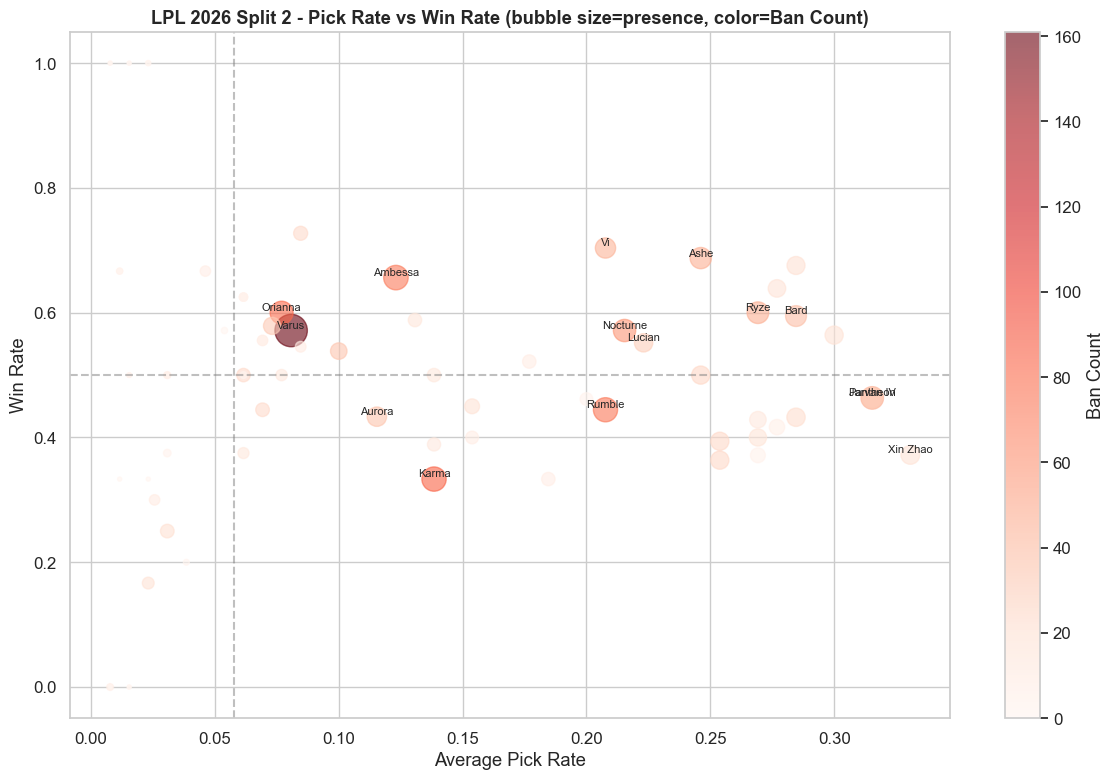

Chart saved: 1d_pickrate_vs_winrate.png


In [22]:
# 1d: Win rate vs Pick rate scatter
fig, ax = plt.subplots(figsize=(12, 8))
scatter = ax.scatter(presence['avg_picks_rate'], presence['win_rate'],
                     s=presence['total_games'] * 3, alpha=0.6, c=presence['total_bans'], cmap='Reds')
for _, row in presence.head(15).iterrows():
    ax.annotate(row['champion'], (row['avg_picks_rate'], row['win_rate']),
                fontsize=8, ha='center', va='bottom')
ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
ax.axvline(x=presence['avg_picks_rate'].median(), color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Average Pick Rate')
ax.set_ylabel('Win Rate')
ax.set_title('LPL 2026 Split 2 - Pick Rate vs Win Rate (bubble size=presence, color=Ban Count)', fontweight='bold')
plt.colorbar(scatter, label='Ban Count')
plt.tight_layout()
plt.show()
plt.savefig(os.path.join(OUTPUT_DIR, '1d_pickrate_vs_winrate.png'), dpi=150)
plt.close()
print("Chart saved: 1d_pickrate_vs_winrate.png")

### High pick rate, low win rate Hero

In [ ]:
high_pick_low_win = cs_s2[(cs_s2['picks_rate'] > 0.1) & (cs_s2['win_rate'] < 0.4)].nlargest(10, 'picks_rate')
if high_pick_low_win.empty:
    print('No high pick low win champions found')
else:
    fig, ax = plt.subplots(figsize=(10, 6))
    bars = ax.barh(high_pick_low_win['champion'], high_pick_low_win['picks_rate'], color=sns.color_palette('viridis', len(high_pick_low_win)))
    ax.set_title('Top Pick Rate - Low Win Rate', fontweight='bold')
    ax.set_xlabel('Pick Rate')
    for bar, wr in zip(bars, high_pick_low_win['win_rate']):
        ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2, f'WR:{wr:.1%}', va='center', fontsize=9)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, '1e_high_pick_low_win.png'), dpi=150)
    plt.show()
    plt.close()
    print("Chart saved: 1e_high_pick_low_win.png")


No high pick low win champions found


### Low pick rate, high win rate Hero

In [ ]:
low_pick_high_win = cs_s2[(cs_s2['picks_rate'] < 0.05) & (cs_s2['win_rate'] > 0.7)].nsmallest(10, 'picks_rate')
if low_pick_high_win.empty:
    print('No low pick high win champions found')
else:
    fig, ax = plt.subplots(figsize=(10, 6))
    bars = ax.barh(low_pick_high_win['champion'], low_pick_high_win['picks_rate'], color=sns.color_palette('viridis', len(low_pick_high_win)))
    ax.set_title('Bottom Pick Rate - High Win Rate', fontweight='bold')
    ax.set_xlabel('Pick Rate')
    for bar, wr in zip(bars, low_pick_high_win['win_rate']):
        ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2, f'WR:{wr:.1%}', va='center', fontsize=9)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, '1f_low_pick_high_win.png'), dpi=150)
    plt.show()
    plt.close()
    print("Chart saved: 1f_low_pick_high_win.png")


Chart saved: 1f_low_pick_high_win.png


## Analysis 2: Hot Champion Synergy Analysis

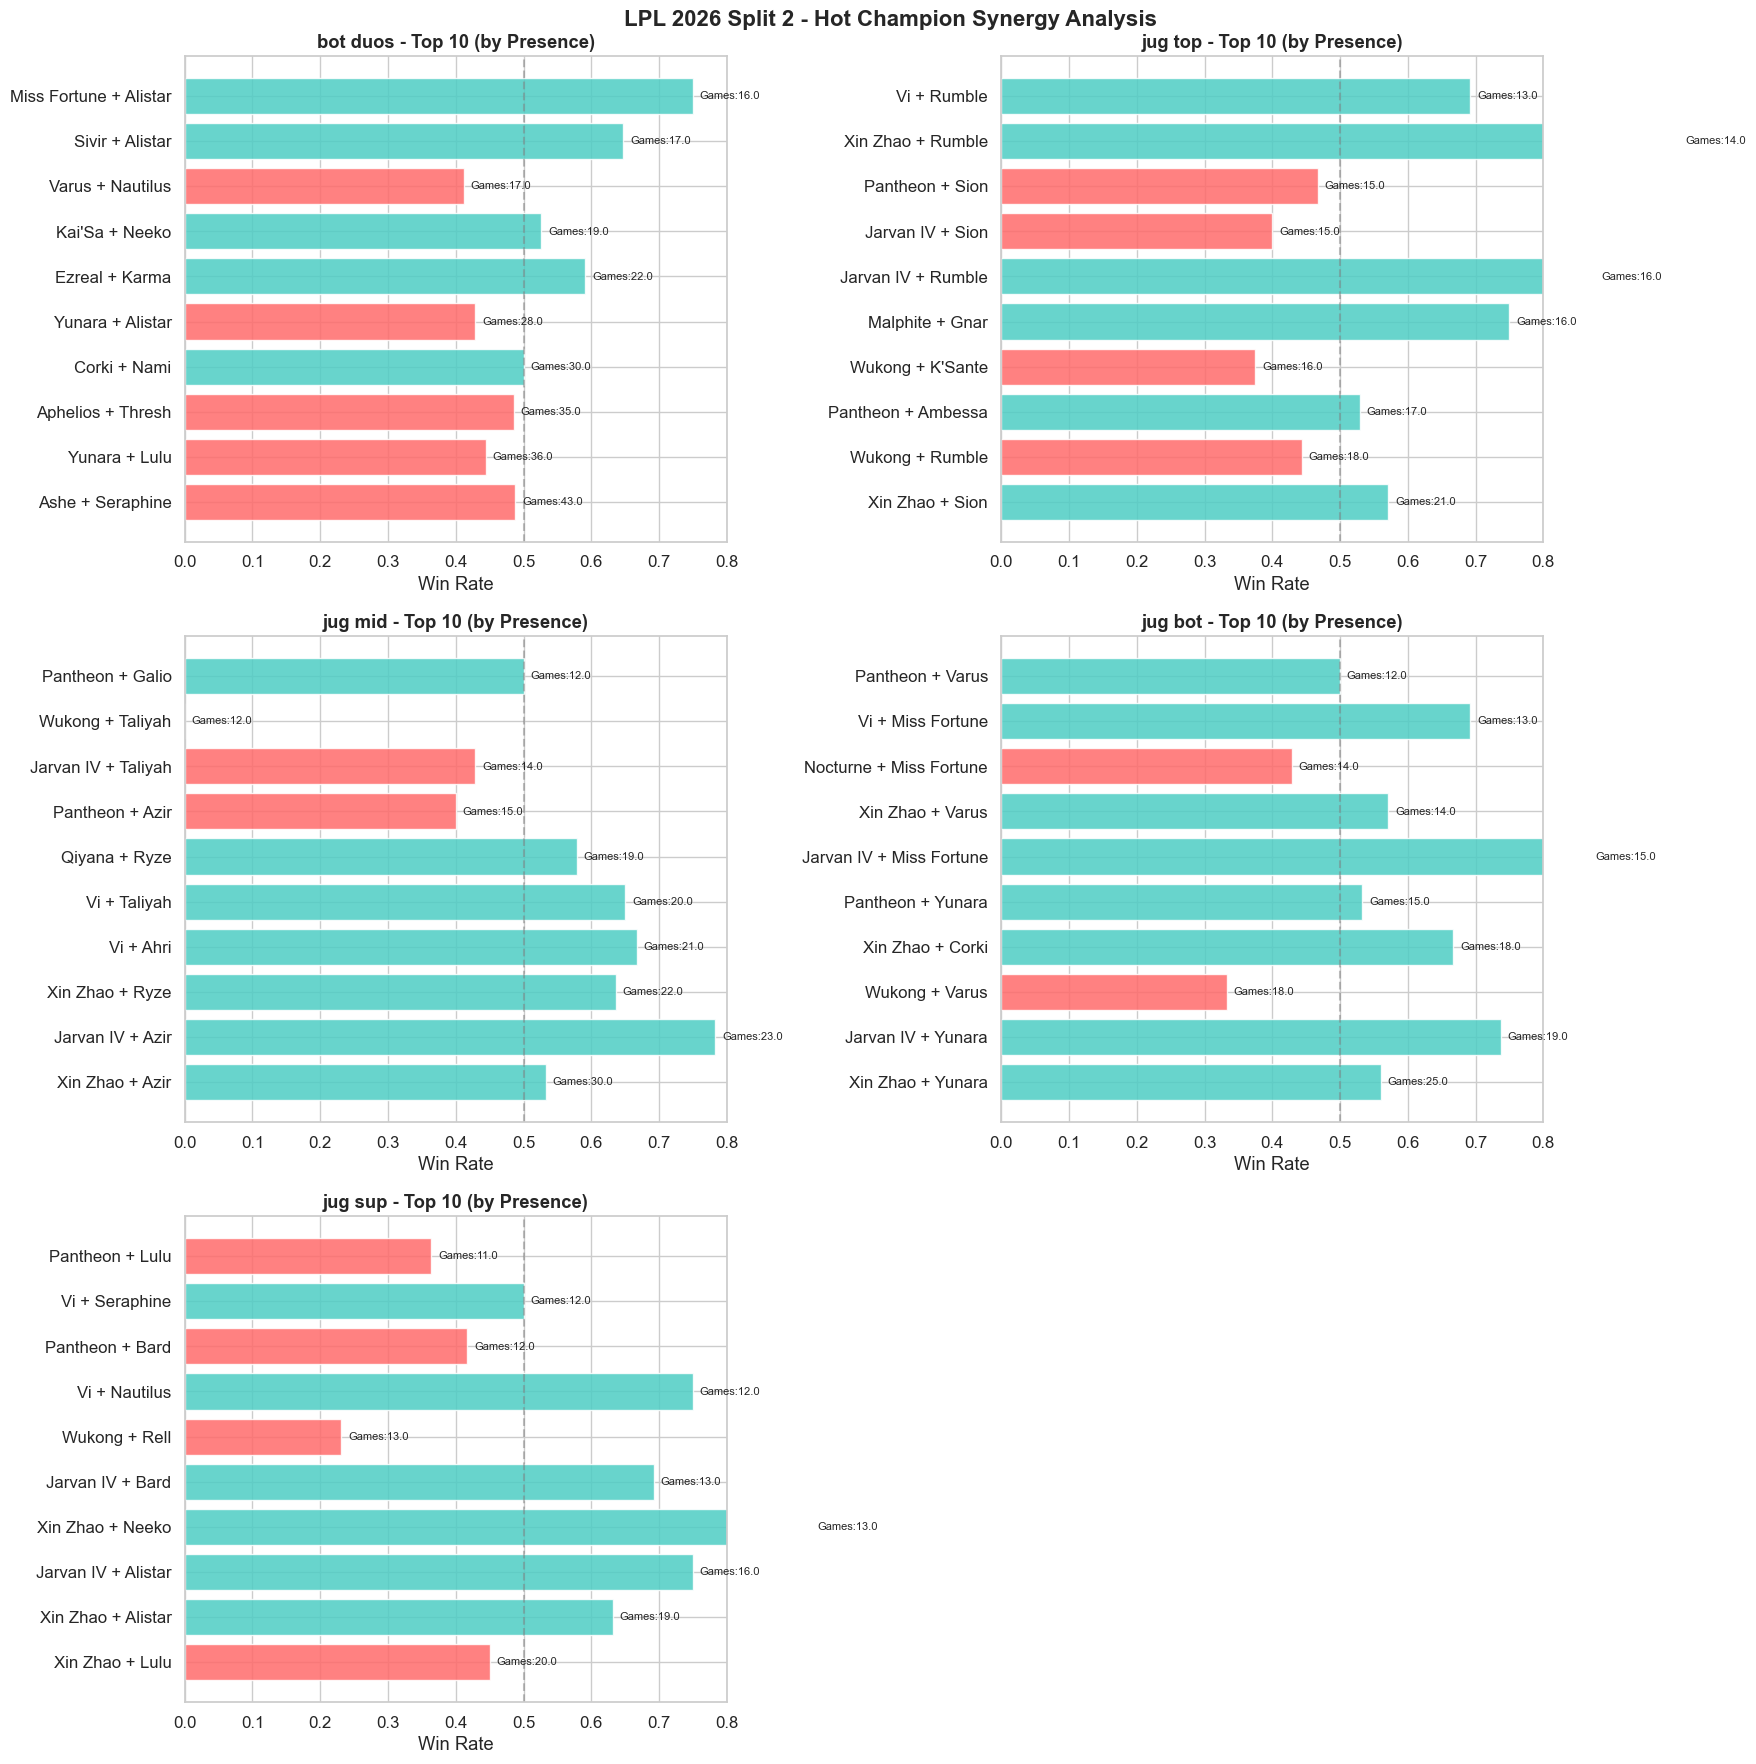

Chart saved: 2a_synergy_by_category.png


In [25]:
# 2a: Top synergy pairs by category
categories_map = {
    'bot duos': '下路双人组 (Bot Duos)',
    'jug top': '上野组合 (Jungle-Top)',
    'jug mid': '中野组合 (Jungle-Mid)',
    'jug bot': '下野组合 (Jungle-Bot)',
    'jug sup': '野辅组合 (Jungle-Support)',
}

fig, axes = plt.subplots(3, 2, figsize=(18, 18))
for idx, (cat, cat_cn) in enumerate(categories_map.items()):
    ax = axes[idx // 2][idx % 2]
    cat_data = synergy[synergy['category'] == cat].nlargest(10, 'games')
    if cat_data.empty:
        ax.set_title(f'{cat_cn} - No Data')
        continue
    labels = [f"{r['champion1']} + {r['champion2']}" for _, r in cat_data.iterrows()]
    colors = ['#4ECDC4' if wr >= 0.5 else '#FF6B6B' for wr in cat_data['win_rate']]
    bars = ax.barh(labels, cat_data['win_rate'], color=colors, alpha=0.85)
    ax.set_xlim(0, 0.8)
    ax.axvline(x=0.5, color='gray', linestyle='--', alpha=0.5)
    ax.set_title(f'{cat} - Top 10 (by Presence)', fontweight='bold')
    ax.set_xlabel('Win Rate')
    for bar, games in zip(bars, cat_data['games']):
        ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2, f'Games:{games:.1f}', va='center', fontsize=8)
axes[2][1].axis('off')
plt.suptitle('LPL 2026 Split 2 - Hot Champion Synergy Analysis', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()
plt.savefig(os.path.join(OUTPUT_DIR, '2a_synergy_by_category.png'), dpi=150)
plt.close()
print("Chart saved: 2a_synergy_by_category.png")


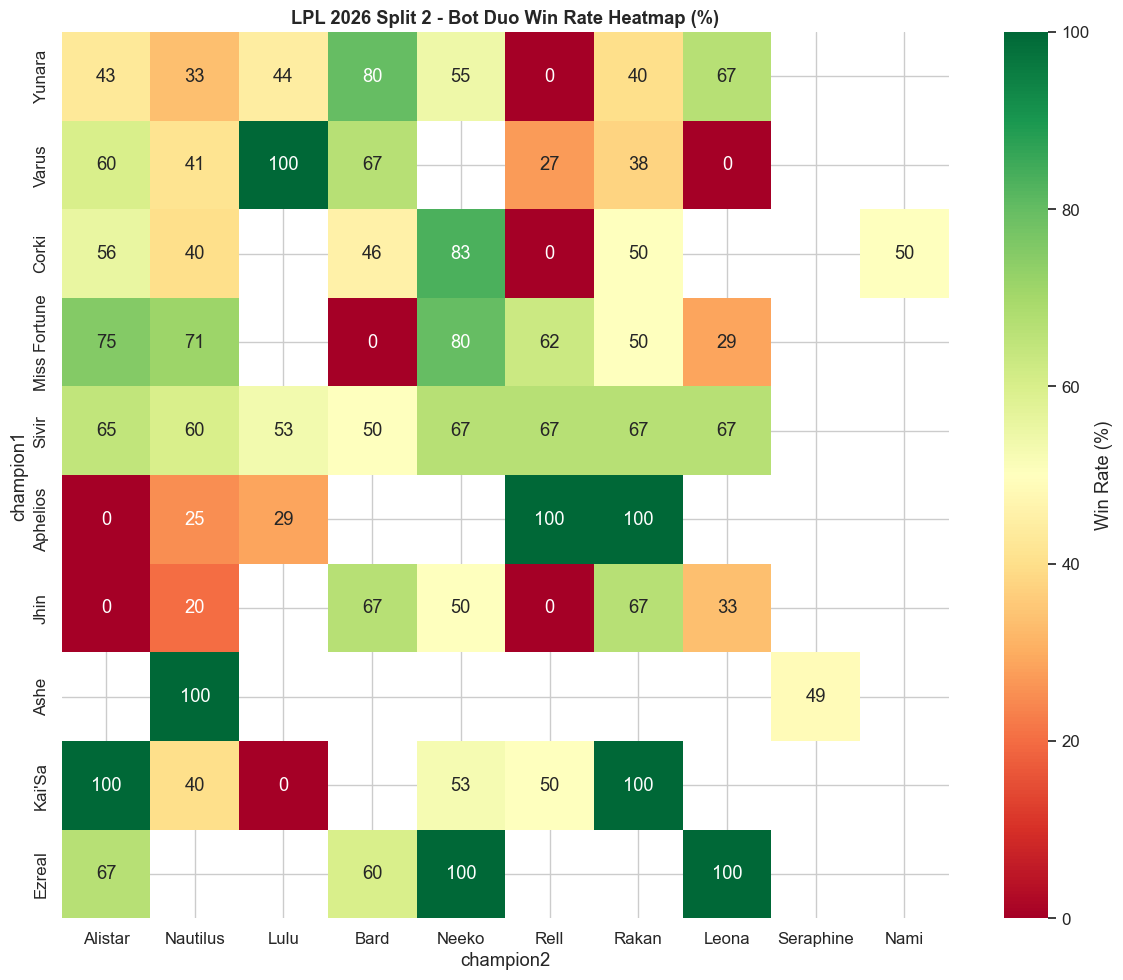

Chart saved: 2b_bot_duo_heatmap.png


In [26]:
# 2c: Synergy heatmap for bot duos
bot_duos = synergy[synergy['category'] == 'bot duos'].copy()
if not bot_duos.empty:
    # 计算每个bot英雄（champion1）的总games，取top10
    champ_games_bot = bot_duos.groupby('champion1')['games'].sum().nlargest(10)
    sorted_bots = champ_games_bot.index.tolist()  # y轴：bot英雄，按games降序
    
    # 计算每个support英雄（champion2）的总games，取top10
    champ_games_support = bot_duos.groupby('champion2')['games'].sum().nlargest(10)
    sorted_supports = champ_games_support.index.tolist()  # x轴：support英雄，按games降序
    
    # 创建pivot table，只包含这些英雄的组合
    pivot = bot_duos.pivot_table(index='champion1', columns='champion2', values='win_rate', fill_value=np.nan)
    # 限制到top10英雄，排除无数据英雄
    pivot = pivot.reindex(index=sorted_bots, columns=sorted_supports)
    
    # 将win_rate转换为百分数（乘100）
    pivot = pivot * 100
    
    # 绘制热力图
    fig, ax = plt.subplots(figsize=(12, 10))
    sns.heatmap(pivot, annot=True, cmap='RdYlGn', fmt='.0f', center=50, ax=ax, cbar_kws={'label': 'Win Rate (%)'})
    ax.set_title('LPL 2026 Split 2 - Bot Duo Win Rate Heatmap (%)', fontweight='bold')
    plt.tight_layout()
    plt.show()
    plt.savefig(os.path.join(OUTPUT_DIR, '2b_bot_duo_heatmap.png'), dpi=150)
    plt.close()
    print("Chart saved: 2b_bot_duo_heatmap.png")


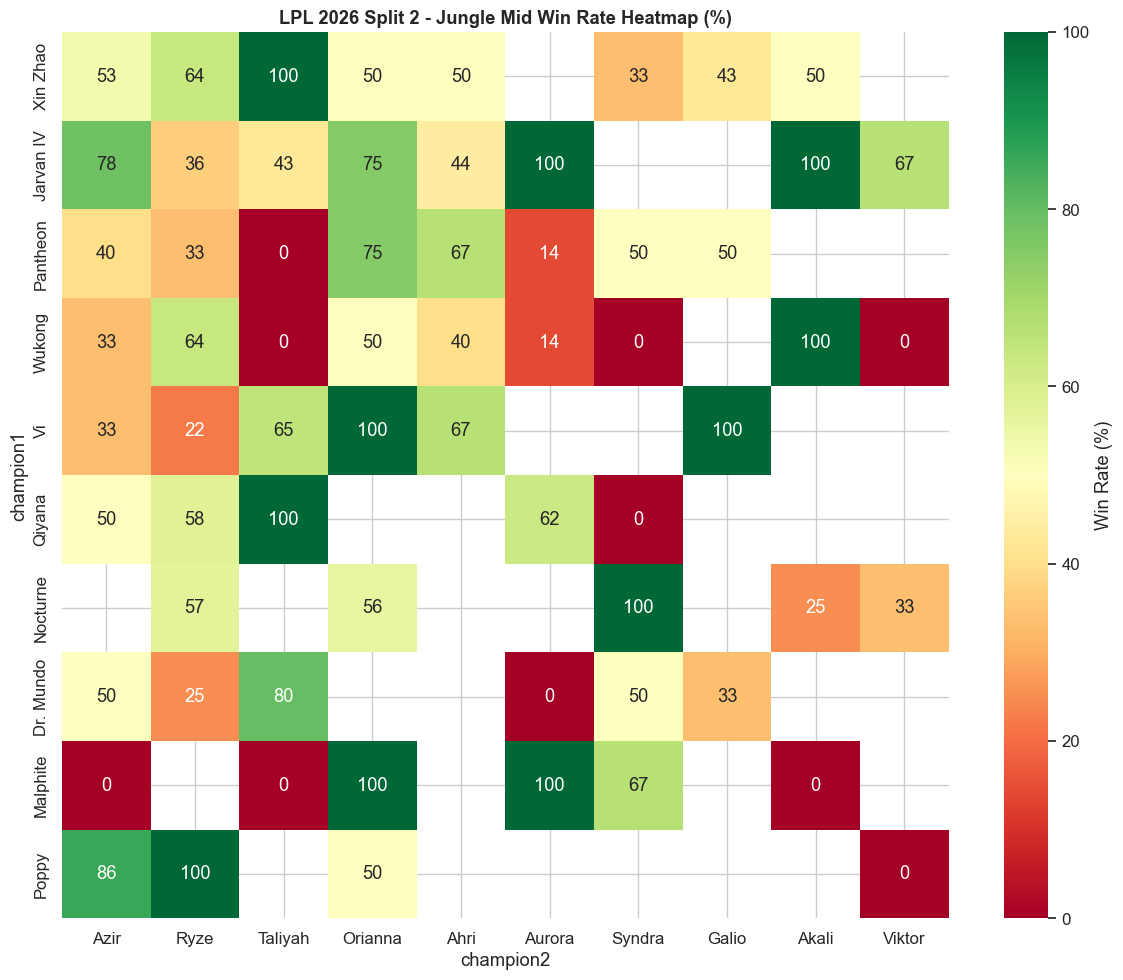

Chart saved: 2b_jug_mid_heatmap.png


In [27]:
# 2c: Synergy heatmap for jungle mid
jug_mid = synergy[synergy['category'] == 'jug mid'].copy()
if not jug_mid.empty:
    # 计算每个jungle英雄（champion1）的总games，取top10
    champ_games_jug_mid = jug_mid.groupby('champion1')['games'].sum().nlargest(10)
    sorted_jug_mid = champ_games_jug_mid.index.tolist()  # y轴：jungle英雄，按games降序
    
    # 计算每个mid英雄（champion2）的总games，取top10
    champ_games_support = jug_mid.groupby('champion2')['games'].sum().nlargest(10)
    sorted_supports = champ_games_support.index.tolist()  # x轴：mid英雄，按games降序
    
    # 创建pivot table，只包含这些英雄的组合
    pivot = jug_mid.pivot_table(index='champion1', columns='champion2', values='win_rate', fill_value=np.nan)
    # 限制到top10英雄，排除无数据英雄
    pivot = pivot.reindex(index=sorted_jug_mid, columns=sorted_supports)
    
    # 将win_rate转换为百分数（乘100）
    pivot = pivot * 100
    
    # 绘制热力图
    fig, ax = plt.subplots(figsize=(12, 10))
    sns.heatmap(pivot, annot=True, cmap='RdYlGn', fmt='.0f', center=50, ax=ax, cbar_kws={'label': 'Win Rate (%)'})
    ax.set_title('LPL 2026 Split 2 - Jungle Mid Win Rate Heatmap (%)', fontweight='bold')
    plt.tight_layout()
    plt.show()
    plt.savefig(os.path.join(OUTPUT_DIR, '2b_jug_mid_heatmap.png'), dpi=150)
    plt.close()
    print("Chart saved: 2b_jug_mid_heatmap.png")


In [28]:
# 2c: Print top synergy pairs
for cat, cat_cn in categories_map.items():
    cat_data = synergy[synergy['category'] == cat].nlargest(5, 'games')
    print(f"\n{cat_cn}:")
    for _, r in cat_data.iterrows():
        print(f"  {r['champion1']} + {r['champion2']}: WR={r['win_rate']:.1%}, Games={r['games']}, Score={r['score']:.1f}")



下路双人组 (Bot Duos):
  Ashe + Seraphine: WR=48.8%, Games=43, Score=34.6
  Yunara + Lulu: WR=44.4%, Games=36, Score=29.5
  Aphelios + Thresh: WR=48.6%, Games=35, Score=33.0
  Corki + Nami: WR=50.0%, Games=30, Score=33.2
  Yunara + Alistar: WR=42.9%, Games=28, Score=26.5

上野组合 (Jungle-Top):
  Xin Zhao + Sion: WR=57.1%, Games=21, Score=36.5
  Wukong + Rumble: WR=44.4%, Games=18, Score=24.5
  Pantheon + Ambessa: WR=52.9%, Games=17, Score=30.9
  Wukong + K'Sante: WR=37.5%, Games=16, Score=18.5
  Malphite + Gnar: WR=75.0%, Games=16, Score=50.5

中野组合 (Jungle-Mid):
  Xin Zhao + Azir: WR=53.3%, Games=30, Score=36.1
  Jarvan IV + Azir: WR=78.3%, Games=23, Score=58.1
  Xin Zhao + Ryze: WR=63.6%, Games=22, Score=42.9
  Vi + Ahri: WR=66.7%, Games=21, Score=45.4
  Vi + Taliyah: WR=65.0%, Games=20, Score=43.3

下野组合 (Jungle-Bot):
  Xin Zhao + Yunara: WR=56.0%, Games=25, Score=37.1
  Jarvan IV + Yunara: WR=73.7%, Games=19, Score=51.2
  Wukong + Varus: WR=33.3%, Games=18, Score=16.3
  Xin Zhao + Corki: WR

## Analysis 3: Draft Trend Analysis

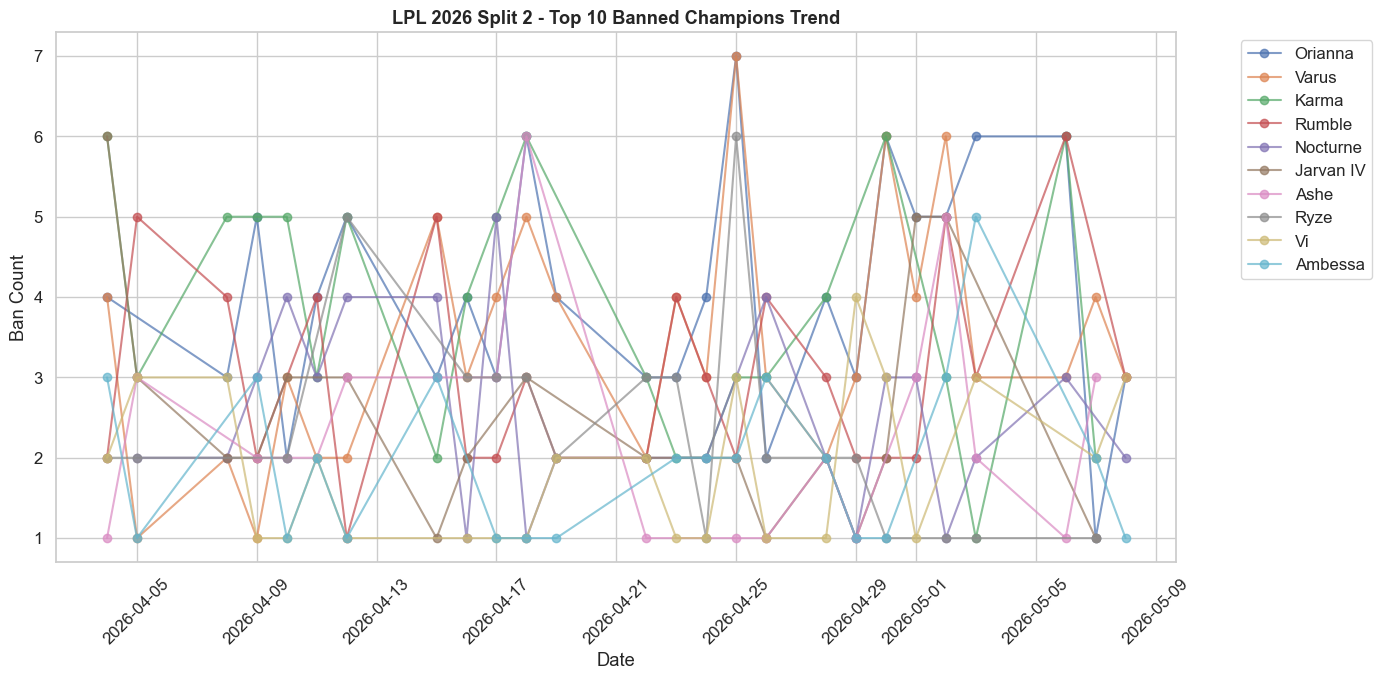

Chart saved: 3a_ban_trends.png


In [29]:
# 3a: Ban trends by date
if not teams_s2.empty:
    ban_cols = ['ban1', 'ban2', 'ban3', 'ban4', 'ban5']
    all_bans = teams_s2.melt(id_vars=['gameid', 'date', 'side'], value_vars=ban_cols, value_name='banned_champion')
    all_bans = all_bans.dropna(subset=['banned_champion'])
    all_bans = all_bans[all_bans['banned_champion'] != 'Unknown']
    
    ban_by_date = all_bans.groupby([all_bans['date'].dt.date, 'banned_champion']).size().reset_index(name='ban_count')
    ban_by_date.columns = ['date', 'banned_champion', 'ban_count']
    top_banned = all_bans['banned_champion'].value_counts().nlargest(10).index.tolist()
    
    fig, ax = plt.subplots(figsize=(14, 7))
    for champ in top_banned:
        champ_data = ban_by_date[ban_by_date['banned_champion'] == champ].sort_values('date')
        if len(champ_data) > 1:
            ax.plot(champ_data['date'], champ_data['ban_count'], 'o-', label=champ, alpha=0.7)
    ax.set_xlabel('Date')
    ax.set_ylabel('Ban Count')
    ax.set_title('LPL 2026 Split 2 - Top 10 Banned Champions Trend', fontweight='bold')
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    plt.savefig(os.path.join(OUTPUT_DIR, '3a_ban_trends.png'), dpi=150)
    plt.close()
    print("Chart saved: 3a_ban_trends.png")


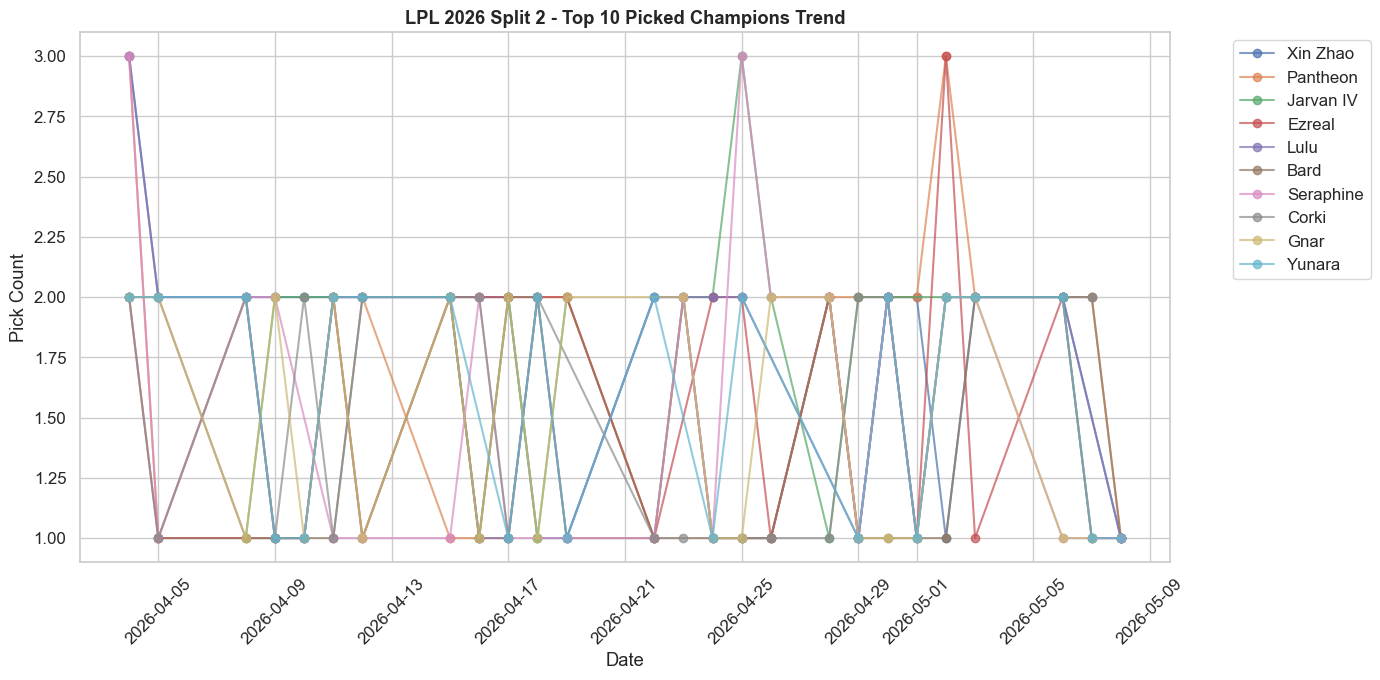

Chart saved: 3b_pick_trends.png


In [30]:
# 3b: Pick trends by date
if not players_s2.empty:
    pick_by_date = players_s2.groupby([players_s2['date'].dt.date, 'champion']).size().reset_index(name='pick_count')
    pick_by_date.columns = ['date', 'champion', 'pick_count']
    top_picked = players_s2['champion'].value_counts().nlargest(10).index.tolist()
    
    fig, ax = plt.subplots(figsize=(14, 7))
    for champ in top_picked:
        champ_data = pick_by_date[pick_by_date['champion'] == champ].sort_values('date')
        if len(champ_data) > 1:
            ax.plot(champ_data['date'], champ_data['pick_count'], 'o-', label=champ, alpha=0.7)
    ax.set_xlabel('Date')
    ax.set_ylabel('Pick Count')
    ax.set_title('LPL 2026 Split 2 - Top 10 Picked Champions Trend', fontweight='bold')
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    plt.savefig(os.path.join(OUTPUT_DIR, '3b_pick_trends.png'), dpi=150)
    plt.close()
    print("Chart saved: 3b_pick_trends.png")


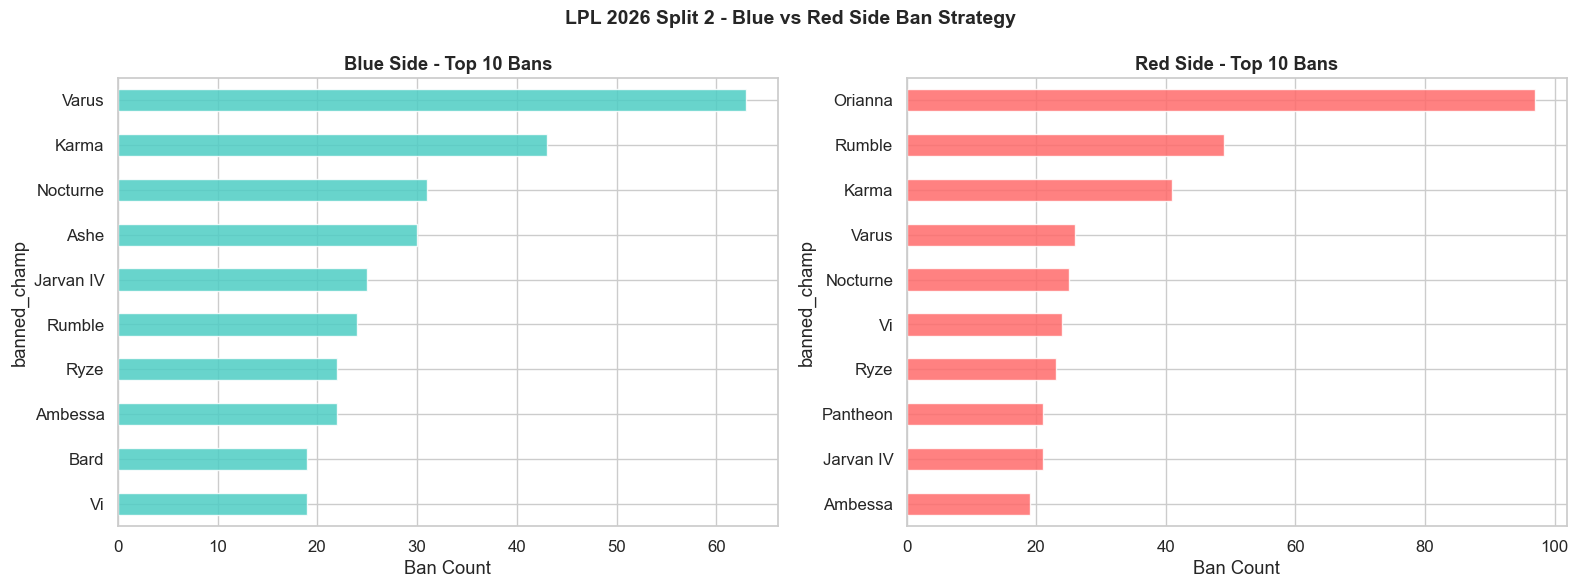

Chart saved: 3c_blue_red_ban_strategy.png


In [31]:
# 3c: Blue vs Red side ban/pick strategy
if not teams_s2.empty:
    blue = teams_s2[teams_s2['side'] == 'Blue']
    red = teams_s2[teams_s2['side'] == 'Red']
    
    blue_bans = blue.melt(value_vars=ban_cols, value_name='banned_champ')['banned_champ'].value_counts().head(10)
    red_bans = red.melt(value_vars=ban_cols, value_name='banned_champ')['banned_champ'].value_counts().head(10)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    blue_bans.sort_values().plot(kind='barh', ax=ax1, color='#4ECDC4', alpha=0.85)
    ax1.set_title('Blue Side - Top 10 Bans', fontweight='bold')
    ax1.set_xlabel('Ban Count')
    red_bans.sort_values().plot(kind='barh', ax=ax2, color='#FF6B6B', alpha=0.85)
    ax2.set_title('Red Side - Top 10 Bans', fontweight='bold')
    ax2.set_xlabel('Ban Count')
    plt.suptitle('LPL 2026 Split 2 - Blue vs Red Side Ban Strategy', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    plt.savefig(os.path.join(OUTPUT_DIR, '3c_blue_red_ban_strategy.png'), dpi=150)
    plt.close()
    print("Chart saved: 3c_blue_red_ban_strategy.png")



Blue side win rate: 45.3%
Red side win rate: 54.7%


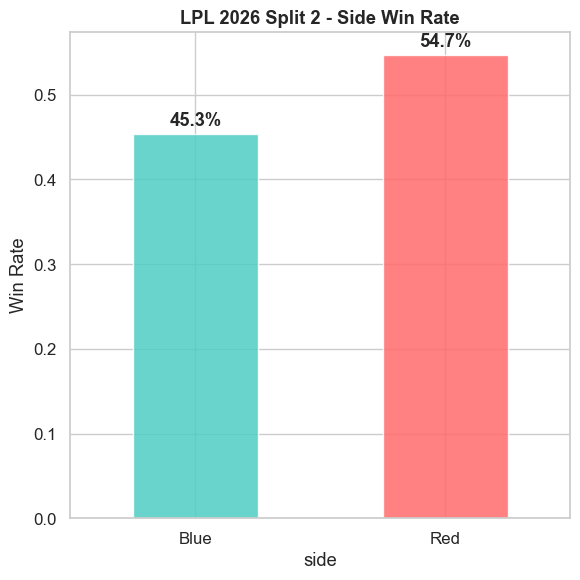

Chart saved: 3d_side_winrate.png


In [32]:
# 3d: Side win rate
if not teams_s2.empty:
    side_wr = teams_s2.groupby('side')['result'].mean()
    print(f"\nBlue side win rate: {side_wr.get('Blue', 0):.1%}")
    print(f"Red side win rate: {side_wr.get('Red', 0):.1%}")
    
    fig, ax = plt.subplots(figsize=(6, 6))
    colors = ['#4ECDC4', '#FF6B6B']
    side_wr.plot(kind='bar', ax=ax, color=colors, alpha=0.85)
    ax.set_title('LPL 2026 Split 2 - Side Win Rate', fontweight='bold')
    ax.set_ylabel('Win Rate')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    for i, v in enumerate(side_wr):
        ax.text(i, v + 0.01, f'{v:.1%}', ha='center', fontweight='bold')
    plt.tight_layout()
    plt.show()
    plt.savefig(os.path.join(OUTPUT_DIR, '3d_side_winrate.png'), dpi=150)
    plt.close()
    print("Chart saved: 3d_side_winrate.png")


## Analysis 4: Hot draft strategy

  ['Lulu', 'Xin Zhao', 'Yunara']: 7次, 胜率=42.9%
  ['Ashe', 'Jarvan IV', 'Seraphine']: 7次, 胜率=57.1%
  ['Ashe', 'Seraphine', 'Xin Zhao']: 5次, 胜率=60.0%
  ['Corki', 'Jarvan IV', 'Nami']: 5次, 胜率=60.0%
  ['Corki', 'Nami', 'Pantheon']: 4次, 胜率=25.0%
  ['Lucian', 'Milio', 'Nocturne']: 4次, 胜率=75.0%
  ['Ahri', 'Rumble', 'Vi']: 3次, 胜率=33.3%
  ['Ambessa', 'Ashe', 'Seraphine']: 3次, 胜率=66.7%
  ['Ashe', 'Pantheon', 'Seraphine']: 3次, 胜率=100.0%
  ['Ambessa', 'Bard', 'Ezreal']: 3次, 胜率=100.0%
  ['Bard', 'Ezreal', 'Jarvan IV']: 3次, 胜率=66.7%
  ['Corki', 'Jayce', 'Nami']: 2次, 胜率=0.0%
  ['Pantheon', 'Ryze', 'Sion']: 2次, 胜率=100.0%
  ['Lulu', 'Nocturne', 'Yunara']: 2次, 胜率=50.0%
  ['Ashe', 'Gnar', 'Seraphine']: 2次, 胜率=100.0%
  ['Caitlyn', 'Karma', 'Nocturne']: 2次, 胜率=50.0%
  ['Corki', 'Nami', 'Orianna']: 2次, 胜率=50.0%
  ['Bard', 'Ezreal', 'Gnar']: 2次, 胜率=100.0%
  ['Lulu', 'Pantheon', 'Yunara']: 2次, 胜率=0.0%
  ['Ezreal', 'Pantheon', 'Ryze']: 2次, 胜率=50.0%
  ['Bard', 'Ezreal', 'Pantheon']: 2次, 胜率=50.0%
  ['Ahri', 'Jay

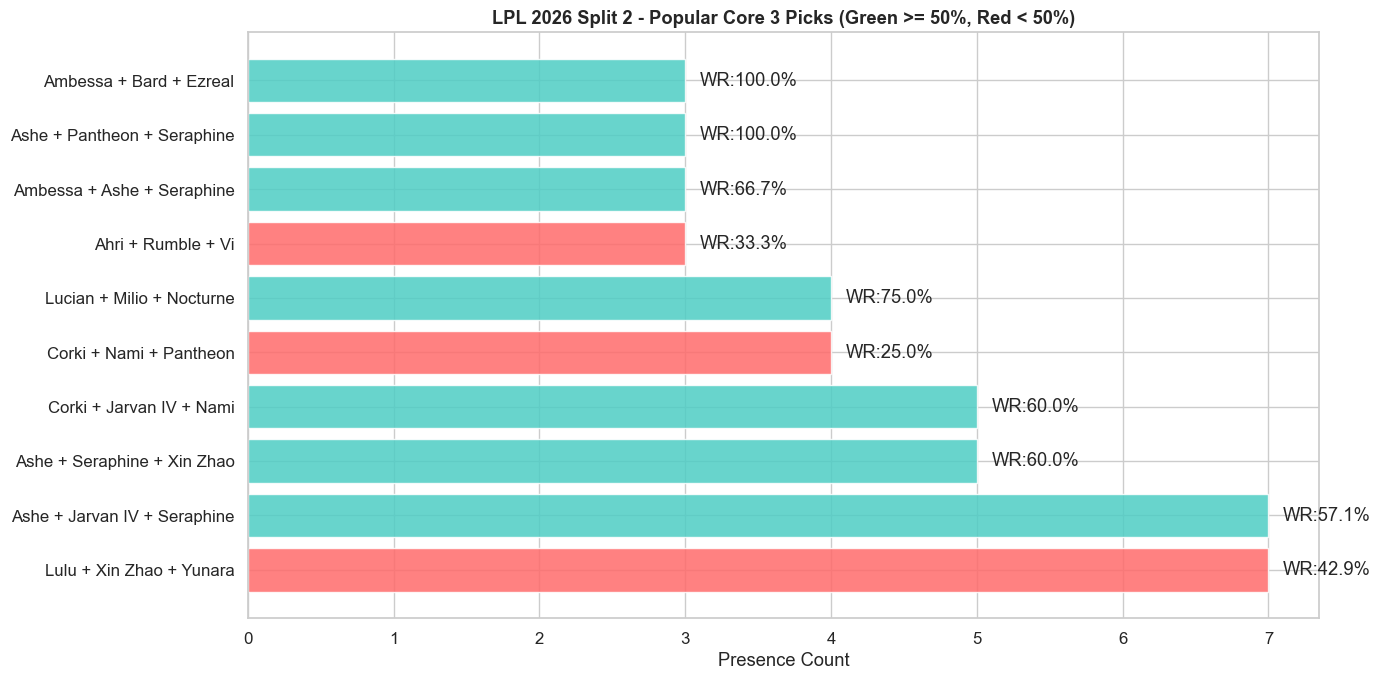

Chart saved: 4a_core3_compositions.png


In [33]:
# 4a: Most common draft compositions
if not teams_s2.empty:
    pick_cols_team = ['pick1', 'pick2', 'pick3', 'pick4', 'pick5']
    
    # Build team compositions
    team_comps = []
    for gameid in teams_s2['gameid'].unique():
        game_teams = teams_s2[teams_s2['gameid'] == gameid]
        for _, team in game_teams.iterrows():
            picks = [team.get(f'pick{i}') for i in range(1, 6)]
            picks = [p for p in picks if pd.notna(p) and p != 'Unknown']
            bans = [team.get(f'ban{i}') for i in range(1, 6)]
            bans = [b for b in bans if pd.notna(b) and b != 'Unknown']
            if len(picks) >= 3:
                team_comps.append({
                    'gameid': gameid,
                    'side': team['side'],
                    'result': team['result'],
                    'picks': picks,
                    'bans': bans,
                    'core3': tuple(sorted(picks[:3])),
                })
    
    comp_df = pd.DataFrame(team_comps)
    
    # Find most common core-3 combinations
    if not comp_df.empty:
        core3_counts = comp_df['core3'].value_counts()
        core3_counts = core3_counts[core3_counts > 1]
        for comp, count in core3_counts.items():
            wr = comp_df[comp_df['core3'] == comp]['result'].mean()
            print(f"  {list(comp)}: {count}次, 胜率={wr:.1%}")
        
        # Chart: Top 10 core-3 combinations
        fig, ax = plt.subplots(figsize=(14, 7))
        labels = [' + '.join(list(c)) for c in core3_counts.head(10).index]
        wrs = [comp_df[comp_df['core3'] == c]['result'].mean() for c in core3_counts.head(10).index]
        colors = ['#4ECDC4' if wr >= 0.5 else '#FF6B6B' for wr in wrs]
        bars = ax.barh(labels, core3_counts.head(10).values, color=colors, alpha=0.85)
        ax.set_xlabel('Presence Count')
        ax.set_title('LPL 2026 Split 2 - Popular Core 3 Picks (Green >= 50%, Red < 50%)', fontweight='bold')
        for bar, wr in zip(bars, wrs):
            ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2, f'WR:{wr:.1%}', va='center')
        plt.tight_layout()
        plt.show()
        plt.savefig(os.path.join(OUTPUT_DIR, '4a_core3_compositions.png'), dpi=150)
        plt.close()
        print("Chart saved: 4a_core3_compositions.png")


In [34]:
# 4b: BP Template - Core + Flexible slots
# For each position, find the most picked champion, then find what other champions they're paired with
if not players_s2.empty and not comp_df.empty:
        
    # Get position-champion mapping from matches
    pos_champ = players_s2[['gameid', 'position', 'champion']].drop_duplicates()
    
    # For each game, build full team comp by position
    game_comps = pos_champ.pivot_table(index='gameid', columns='position', values='champion', aggfunc='first').reset_index()
    
    # Merge with results
    game_results = teams_s2[teams_s2['side'] == 'Blue'][['gameid', 'result']].rename(columns={'result': 'blue_win'})
    game_comps = game_comps.merge(game_results, on='gameid', how='left')
    
    # Find synergistic cores: for each pair of positions, find the best performing duo
    position_pairs = [('top', 'jungle'), ('jungle', 'mid'), ('bot', 'support'), ('jungle', 'bot'), ('jungle', 'support')]
    
    print("\n各位置组合最优双人组:")
    duo_results = []
    for pos1, pos2 in position_pairs:
        if pos1 in game_comps.columns and pos2 in game_comps.columns:
            duo_stats = game_comps.groupby([pos1, pos2]).agg(
                count=('gameid', 'count'),
                win_rate=('blue_win', 'mean')
            ).reset_index()
            duo_stats = duo_stats[duo_stats['count'] >= 2].sort_values('count', ascending=False)
            top_duos = duo_stats.head(5)
            print(f"\n  {pos1.upper()} + {pos2.upper()}:")
            for _, r in top_duos.iterrows():
                print(f"    {r[pos1]} + {r[pos2]}: {r['count']}次, 胜率={r['win_rate']:.1%}")
                duo_results.append({
                    'pos1': pos1, 'pos2': pos2,
                    'champ1': r[pos1], 'champ2': r[pos2],
                    'count': r['count'], 'win_rate': r['win_rate']
                })



各位置组合最优双人组:

  TOP + JUNGLE:
    Rumble + Vi: 5次, 胜率=60.0%
    Gnar + Xin Zhao: 5次, 胜率=20.0%
    Rumble + Skarner: 5次, 胜率=40.0%
    Jayce + Vi: 5次, 胜率=80.0%
    Sion + Xin Zhao: 4次, 胜率=50.0%

  JUNGLE + MID:
    Skarner + Azir: 8次, 胜率=37.5%
    Vi + Ahri: 7次, 胜率=71.4%
    Jarvan IV + Azir: 5次, 胜率=40.0%
    Jarvan IV + Aurora: 4次, 胜率=25.0%
    Xin Zhao + Azir: 4次, 胜率=25.0%

  BOT + SUPPORT:
    Yunara + Lulu: 15次, 胜率=26.7%
    Corki + Nami: 13次, 胜率=46.2%
    Ashe + Seraphine: 11次, 胜率=63.6%
    Lucian + Milio: 10次, 胜率=40.0%
    Ezreal + Bard: 9次, 胜率=55.6%

  JUNGLE + BOT:
    Xin Zhao + Jhin: 6次, 胜率=16.7%
    Pantheon + Ezreal: 5次, 胜率=20.0%
    Xin Zhao + Ashe: 5次, 胜率=40.0%
    Xin Zhao + Yunara: 5次, 胜率=40.0%
    Vi + Varus: 4次, 胜率=50.0%

  JUNGLE + SUPPORT:
    Xin Zhao + Seraphine: 6次, 胜率=33.3%
    Xin Zhao + Lulu: 5次, 胜率=40.0%
    Jarvan IV + Nami: 4次, 胜率=75.0%
    Pantheon + Seraphine: 4次, 胜率=75.0%
    Jarvan IV + Bard: 4次, 胜率=25.0%




=== 推荐BP模板（基于Core3 + 多维度适配评分） ===
S2 Total Games: 130

BP模板 #1: Lulu + Xin Zhao + Yunara
  核心出场: 7次 | 核心胜率: 42.9%
  已覆盖位置: Lulu(support), Xin Zhao(jungle), Yunara(bot)
  待补位置: top, mid

  --- 替补英雄推荐（Top 5） ---

  #1 Sion (TOP)
      综合评分: 51.76
      评分明细: 版本强度=30.69, 协同适配=2.88, 克制覆盖=9.64, 属性优势=8.55
      数据: WR=40.0%, PR=26.9%
      选择理由: 版本热门(PR:26.9%); 与Xin Zhao协同优秀(WR:57.1%); 克制对手核心(Xin Zhao)

  #2 Gnar (TOP)
      综合评分: 50.86
      评分明细: 版本强度=33.92, 协同适配=2.36, 克制覆盖=5.73, 属性优势=8.85
      数据: WR=63.9%, PR=27.7%
      选择理由: 版本热门(PR:27.7%); 胜率优异(WR:63.9%); 与Xin Zhao协同优秀(WR:66.7%); 克制对手核心(Xin Zhao); 高DPM(643)

  #3 Ryze (MID)
      综合评分: 47.82
      评分明细: 版本强度=35, 协同适配=3.1, 克制覆盖=0, 属性优势=9.72
      数据: WR=60.0%, PR=26.9%
      选择理由: 版本热门(PR:26.9%); 胜率优异(WR:60.0%); 高Ban率(BR:35.4%); 与Xin Zhao协同优秀(WR:63.6%); 高DPM(655)

  #4 Ambessa (TOP)
      综合评分: 47.13
      评分明细: 版本强度=35, 协同适配=3.03, 克制覆盖=0, 属性优势=9.1
      数据: WR=67.7%, PR=23.8%
      选择理由: 版本热门(PR:23.8%); 胜率优异(WR:67.7%); 高Ban率(BR:31.

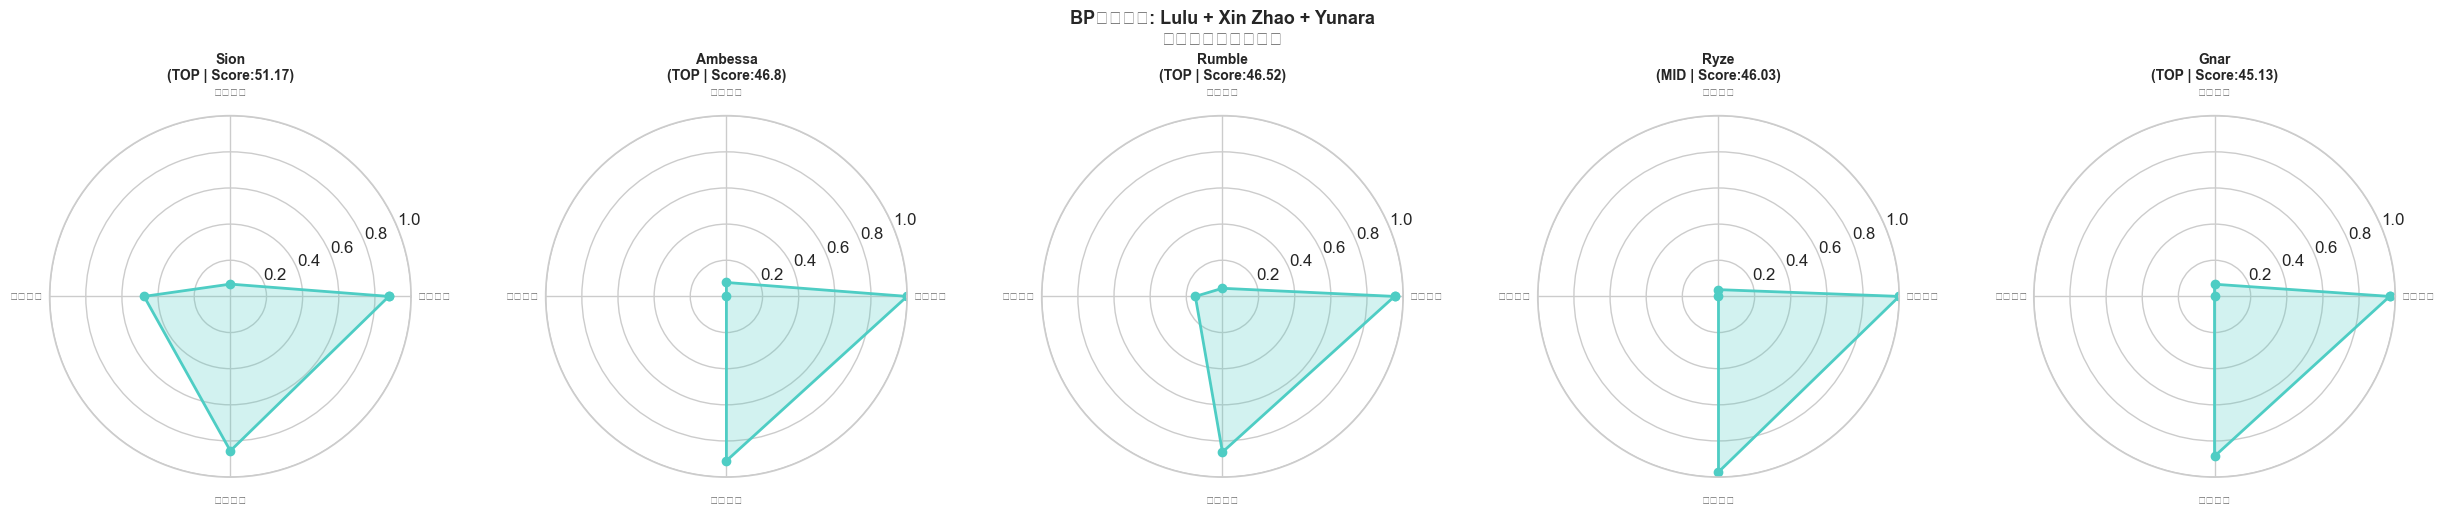


Chart saved: 4c_bp_template_radar.png


In [35]:
# 4c: Build recommended BP templates based on core3 data
if not cs_s2.empty and not comp_df.empty:
    print("\n\n=== 推荐BP模板（基于Core3 + 多维度适配评分） ===")

    champ_pos_map = cs_s2.sort_values('picks', ascending=False).drop_duplicates(subset=['champion'], keep='first').set_index('champion')['position'].to_dict()
    s2_total_games = math.ceil(sum(cs_s2['picks']) / 10) if sum(cs_s2['picks']) > 0 else 0
    print(f"S2 Total Games: {s2_total_games}")
    champ_stats = cs_s2.groupby('champion').agg(
        total_picks=('picks', 'sum'),
        total_wins=('wins', 'sum'),
        total_losses=('losses', 'sum'),
        total_bans=('bans', 'sum'),
        avg_kda=('kda', 'mean'),
        avg_dpm=('dpm', 'mean'),
        avg_dtpm=('dtpm', 'mean'),
        avg_gpm=('gpm', 'mean'),
        avg_cspm=('cspm', 'mean'),
    ).reset_index()

    champ_stats['avg_pick_rate'] = champ_stats['total_picks'] / s2_total_games
    champ_stats['avg_win_rate'] = champ_stats['total_wins'] / s2_total_games
    champ_stats['avg_bans_rate'] = champ_stats['total_bans'] / s2_total_games

    champ_stats = champ_stats.set_index('champion').to_dict('index')
    synergy_pairs = {}
    for _, r in synergy.iterrows():
        key = (r['champion1'], r['champion2'])
        synergy_pairs[key] = {'win_rate': r['win_rate'], 'score': r['score'], 'games': r['games'], 'category': r['category']}
        key_rev = (r['champion2'], r['champion1'])
        synergy_pairs[key_rev] = {'win_rate': r['win_rate'], 'score': r['score'], 'games': r['games'], 'category': r['category']}

    counter_map = {}
    for _, r in counters.iterrows():
        key = (r['champion'], r['opponent_name'])
        if key not in counter_map:
            counter_map[key] = []
        counter_map[key].append({
            'type': r['matchup_type'],
            'opponent_wr': r['opponent_win_rate'],
            'games': r['games'],
        })


    core3_filtered = comp_df['core3'].value_counts()
    core3_filtered = core3_filtered[core3_filtered > 1]

    if not core3_filtered.empty:
        top_cores = core3_filtered.head(5)

        for rank, (core_tuple, count) in enumerate(top_cores.items(), 1):
            core_list = list(core_tuple)
            core_wr = comp_df[comp_df['core3'] == core_tuple]['result'].mean()

            core_positions = []
            for c in core_list:
                pos = champ_pos_map.get(c, 'unknown')
                core_positions.append(pos)

            missing_positions = [p for p in ['top', 'jungle', 'mid', 'bot', 'support'] if p not in core_positions]

            print(f"\n{'='*60}")
            print(f"BP模板 #{rank}: {' + '.join(core_list)}")
            print(f"  核心出场: {count}次 | 核心胜率: {core_wr:.1%}")
            print(f"  已覆盖位置: {', '.join([f'{c}({p})' for c, p in zip(core_list, core_positions)])}")
            print(f"  待补位置: {', '.join(missing_positions)}")

            candidates = []

            for pos in missing_positions:
                pos_champs = cs_s2[cs_s2['position'] == pos]
                for _, champ_row in pos_champs.iterrows():
                    champ = champ_row['champion']
                    if champ in core_list:
                        continue

                    scores = {}
                    reasons = []

                    # Dimension 1: Meta Strength (0-35)
                    pr = champ_row['picks_rate']
                    wr = champ_row['win_rate']
                    br = champ_row['bans_rate']
                    meta_score = min(pr * 75, 15) + min(wr * 30, 15) + min(br * 30, 5)
                    scores['meta'] = round(meta_score, 2)
                    if pr > 0.2:
                        reasons.append(f'版本热门(PR:{pr:.1%})')
                    if wr > 0.55:
                        reasons.append(f'胜率优异(WR:{wr:.1%})')
                    if br > 0.15:
                        reasons.append(f'高Ban率(BR:{br:.1%})')

                    # Dimension 2: Synergy with Core3 (0-35)
                    syn_score = 0
                    best_syn_champ = ''
                    best_syn_wr = 0
                    for core_c in core_list:
                        pair_key = (champ, core_c)
                        if pair_key in synergy_pairs:
                            sp = synergy_pairs[pair_key]
                            pair_score = min(sp['score'] / 10, 12) + min(sp['win_rate'] * 10, 5)
                            if sp['win_rate'] > best_syn_wr:
                                best_syn_wr = sp['win_rate']
                                best_syn_champ = core_c
                            syn_score += pair_score
                    syn_score = min(syn_score / len(core_list), 35)
                    scores['synergy'] = round(syn_score, 2)
                    if best_syn_champ and best_syn_wr > 0.5:
                        reasons.append(f'与{best_syn_champ}协同优秀(WR:{best_syn_wr:.1%})')

                    # Dimension 3: Counter Coverage (0-20)
                    counter_score = 0
                    counter_targets = []
                    for core_c in core_list:
                        key = (champ, core_c)
                        if key in counter_map:
                            for ct in counter_map[key]:
                                # 阈值>0.5，处理NaN
                                wr_val = ct.get('opponent_wr', 0)
                                if pd.isna(wr_val):
                                    wr_val = 0
                                if ct['type'] == 'easy':
                                    counter_score += 3 + wr_val * 100 - 50
                                    counter_targets.append(core_c)
                    counter_score = min(counter_score, 20)  
                    scores['counter'] = round(counter_score, 2)
                    if counter_targets:
                        reasons.append(f'克制对手核心({",".join(counter_targets)})')

                    # Dimension 4: Champion Attributes (0-10)
                    kda = champ_row.get('kda', 0)
                    dpm = champ_row.get('dpm', 0)
                    gpm = champ_row.get('gpm', 0)
                    attr_score = min(kda, 4) + min(dpm / 200, 3) + min(gpm / 100, 3)
                    scores['attributes'] = round(attr_score, 2)
                    if kda > 4:
                        reasons.append(f'高KDA({kda:.1f})')
                    if dpm > 600:
                        reasons.append(f'高DPM({dpm:.0f})')

                    total_score = scores['meta'] + scores['synergy'] + scores['counter'] + scores['attributes']

                    candidates.append({
                        'champion': champ,
                        'position': pos,
                        'total_score': round(total_score, 2),
                        'scores': scores,
                        'reasons': reasons,
                        'win_rate': wr,
                        'picks_rate': pr,
                    })

            candidates.sort(key=lambda x: x['total_score'], reverse=True)

            print(f"\n  --- 替补英雄推荐（Top 5） ---")
            for i, cand in enumerate(candidates[:5], 1):
                s = cand['scores']
                print(f"\n  #{i} {cand['champion']} ({cand['position'].upper()})")
                print(f"      综合评分: {cand['total_score']}")
                print(f"      评分明细: 版本强度={s['meta']}, 协同适配={s['synergy']}, 克制覆盖={s['counter']}, 属性优势={s['attributes']}")
                print(f"      数据: WR={cand['win_rate']:.1%}, PR={cand['picks_rate']:.1%}")
                if cand['reasons']:
                    print(f"      选择理由: {'; '.join(cand['reasons'])}")

        # Visualization: BP Template Radar Chart for top template
        top_core = list(top_cores.index[0])
        top_cands = sorted(candidates, key=lambda x: x['total_score'], reverse=True)[:5]

        if top_cands:
            fig, axes = plt.subplots(1, min(len(top_cands), 5), figsize=(5 * min(len(top_cands), 5), 5), subplot_kw=dict(polar=True))
            if len(top_cands) == 1:
                axes = [axes]

            categories = ['版本强度', '协同适配', '克制覆盖', '属性优势']
            for idx, (ax, cand) in enumerate(zip(axes, top_cands)):
                values = [cand['scores']['meta'], cand['scores']['synergy'], cand['scores']['counter'], cand['scores']['attributes']]
                max_vals = [35, 35, 20, 10]  
                normalized = [v / m for v, m in zip(values, max_vals)]
                normalized += normalized[:1]
                angles = np.linspace(0, 2 * np.pi, len(categories), endpoint=False).tolist()
                angles += angles[:1]

                ax.fill(angles, normalized, alpha=0.25, color='#4ECDC4')
                ax.plot(angles, normalized, 'o-', color='#4ECDC4', linewidth=2)
                ax.set_xticks(angles[:-1])
                ax.set_xticklabels(categories, fontsize=8)
                ax.set_ylim(0, 1)
                ax.set_title(f"{cand['champion']}\n({cand['position'].upper()} | Score:{cand['total_score']})", fontsize=10, fontweight='bold')

            plt.suptitle(f"BP模板核心: {' + '.join(top_core)}\n替补英雄多维度评分", fontsize=13, fontweight='bold')
            plt.tight_layout()
            plt.show()
            plt.savefig(os.path.join(OUTPUT_DIR, '4c_bp_template_radar.png'), dpi=150)
            plt.close()
            print(f"\nChart saved: 4c_bp_template_radar.png")


## Analysis 5: Version Change over split 1 and split 2


Sample Rate Changes:
  champion  s1_picks_rate  s2_picks_rate  pick_rate_change
0   Aatrox       0.037383       0.007692         -0.029691
1     Ahri       0.144860       0.176923          0.032063
2    Akali       0.088785       0.069231         -0.019554
3  Alistar       0.252336       0.076923         -0.175413
4  Ambessa       0.242991       0.246154          0.003163

版本最大赢家 (Pick Rate提升最多):
  Annie: PR 0.5% -> 24.6% (Δ+24.1%), WR 100.0% -> 50.0%
  Jayce: PR 6.1% -> 25.4% (Δ+19.3%), WR 38.5% -> 39.4%
  Ezreal: PR 11.2% -> 30.0% (Δ+18.8%), WR 54.2% -> 56.4%
  Lucian: PR 3.7% -> 22.3% (Δ+18.6%), WR 25.0% -> 55.2%
  Seraphine: PR 10.7% -> 28.5% (Δ+17.7%), WR 47.8% -> 67.6%
  Nami: PR 9.8% -> 26.9% (Δ+17.1%), WR 42.9% -> 42.9%
  Skarner: PR 0.9% -> 15.4% (Δ+14.5%), WR 50.0% -> 45.0%
  Bard: PR 15.4% -> 28.5% (Δ+13.0%), WR 57.6% -> 59.5%
  Gnar: PR 15.0% -> 27.7% (Δ+12.7%), WR 59.4% -> 63.9%
  Lulu: PR 16.8% -> 28.5% (Δ+11.6%), WR 52.8% -> 43.2%

版本最大输家 (Pick Rate下降最多):
  Annie: PR 0.

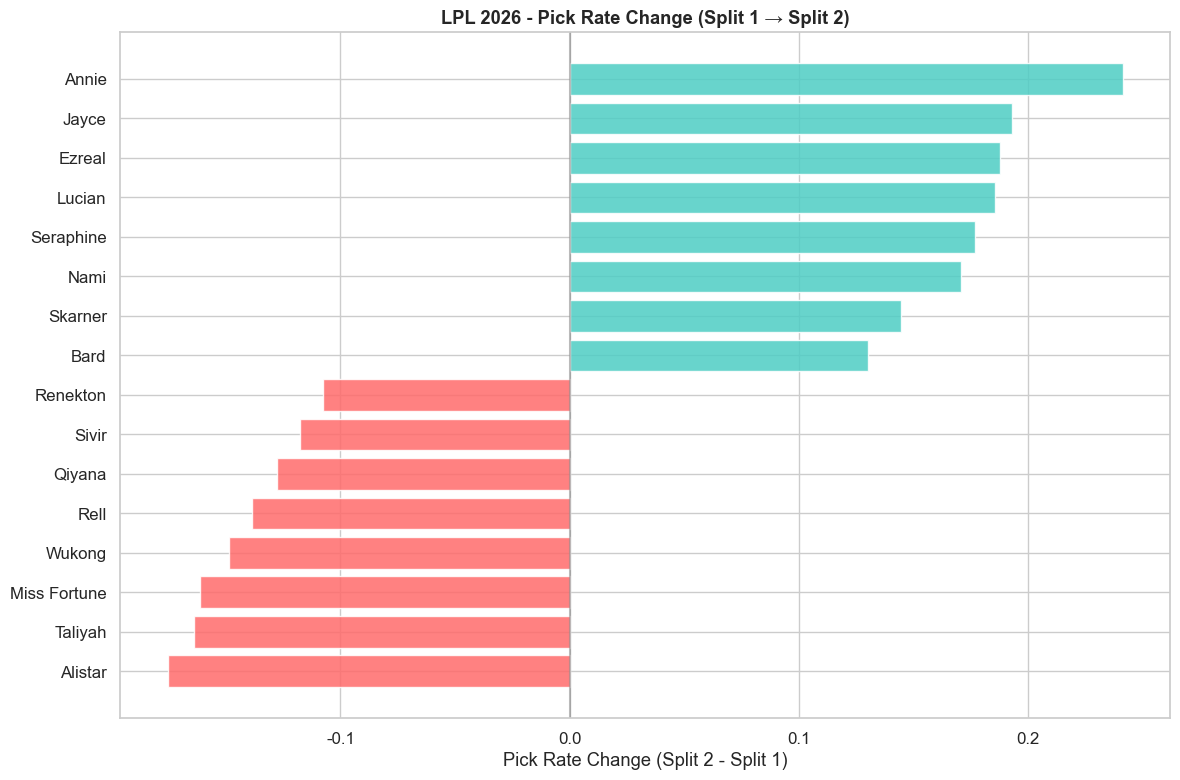

Chart saved: 5b_pickrate_change_bar.png


In [36]:
# Since 2026 Split 2 only has patch 16.07, compare with 2026 Split 1
# cs_s1 already aggregated in data loading cell

if not cs_s1.empty and not cs_s2.empty:

    # Compare champion stats between splits
    s1_agg = cs_s1.groupby('champion').agg(
        s1_picks=('picks', 'sum'),
        s1_bans=('bans', 'sum'),
        s1_wins=('wins', 'sum'),
        s1_losses=('losses', 'sum'),
    ).reset_index()

    s2_agg = cs_s2.groupby('champion').agg(
        s2_picks=('picks', 'sum'),
        s2_bans=('bans', 'sum'),
        s2_wins=('wins', 'sum'),
        s2_losses=('losses', 'sum'),
    ).reset_index()

    s1_total_games = math.ceil(sum(cs_s1['picks']) / 10) if sum(cs_s1['picks']) > 0 else 0
    s2_total_games = math.ceil(sum(cs_s2['picks']) / 10) if sum(cs_s2['picks']) > 0 else 0
    
    s1_agg['s1_win_rate'] = s1_agg['s1_wins'] / (s1_agg['s1_wins'] + s1_agg['s1_losses'])
    s1_agg['s1_picks_rate'] = s1_agg['s1_picks'] / s1_total_games if s1_total_games > 0 else 0  
    s1_agg['s1_bans_rate'] = s1_agg['s1_bans'] / s1_total_games if s1_total_games > 0 else 0  
    
   
    
    s2_agg['s2_win_rate'] = s2_agg['s2_wins'] / (s2_agg['s2_wins'] + s2_agg['s2_losses'])
    s2_agg['s2_picks_rate'] = s2_agg['s2_picks'] / s2_total_games if s2_total_games > 0 else 0  
    s2_agg['s2_bans_rate'] = s2_agg['s2_bans'] / s2_total_games if s2_total_games > 0 else 0  
    
    comparison = s1_agg.merge(s2_agg, on='champion', how='outer').fillna(0)
    comparison['pick_rate_change'] = comparison['s2_picks_rate'] - comparison['s1_picks_rate']
    comparison['win_rate_change'] = comparison['s2_win_rate'] - comparison['s1_win_rate']
    comparison['ban_rate_change'] = comparison['s2_bans_rate'] - comparison['s1_bans_rate']
    
    # 打印前5个英雄的rate和change
    print("\nSample Rate Changes:")
    print(comparison[['champion', 's1_picks_rate', 's2_picks_rate', 'pick_rate_change']].head(5))
    
    # Champions that appeared in both splits
    both = comparison[(comparison['s1_picks'] > 0) & (comparison['s2_picks'] > 0)].copy()
    
    # Biggest risers and fallers
    print("\n版本最大赢家 (Pick Rate提升最多):")
    risers = both.nlargest(10, 'pick_rate_change')
    for _, r in risers.iterrows():
        print(f"  {r['champion']}: PR {r['s1_picks_rate']:.1%} -> {r['s2_picks_rate']:.1%} (Δ{r['pick_rate_change']:+.1%}), WR {r['s1_win_rate']:.1%} -> {r['s2_win_rate']:.1%}")
    
    print("\n版本最大输家 (Pick Rate下降最多):")
    fallers = both.nsmallest(10, 'pick_rate_change')
    for _, r in risers.iterrows():
        print(f"  {r['champion']}: PR {r['s1_picks_rate']:.1%} -> {r['s2_picks_rate']:.1%} (Δ{r['pick_rate_change']:+.1%}), WR {r['s1_win_rate']:.1%} -> {r['s2_win_rate']:.1%}")
    
    # Chart 5a: Pick rate change vs Win rate change
    if not both.empty:
        fig, ax = plt.subplots(figsize=(14, 10))
        scatter = ax.scatter(both['pick_rate_change'], both['win_rate_change'],
                           s=abs(both['s2_picks']) * 5 + 20, alpha=0.6,
                           c=both['s2_picks_rate'], cmap='YlOrRd')
        # 标注Top变化英雄（减少数量以突出）
        for _, r in both.nlargest(5, 'pick_rate_change').iterrows():
            ax.annotate(r['champion'], (r['pick_rate_change'], r['win_rate_change']),
                       fontsize=8, ha='center', va='bottom', color='green')
        for _, r in both.nsmallest(5, 'pick_rate_change').iterrows():
            ax.annotate(r['champion'], (r['pick_rate_change'], r['win_rate_change']),
                       fontsize=8, ha='center', va='bottom', color='red')
        ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
        ax.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
        ax.set_xlabel('Pick Rate Change (Split 2 - Split 1, 百分点)')
        ax.set_ylabel('Win Rate Change (Split 2 - Split 1, 百分点)')
        ax.set_title('LPL 2026 - 版本更新前后英雄强度变化 (Split 1 → Split 2)', fontweight='bold')
        plt.colorbar(scatter, label='Split 2 Pick Rate (%)')
        
        # Add quadrant labels
        ax.text(0.95, 0.95, '崛起英雄\n(PR↑ WR↑)', transform=ax.transAxes, ha='right', va='top', fontsize=10, color='green', fontweight='bold')
        ax.text(0.05, 0.95, '版本陷阱\n(PR↓ WR↑)', transform=ax.transAxes, ha='left', va='top', fontsize=10, color='orange', fontweight='bold')
        ax.text(0.95, 0.05, '版本陷阱\n(PR↑ WR↓)', transform=ax.transAxes, ha='right', va='bottom', fontsize=10, color='orange', fontweight='bold')
        ax.text(0.05, 0.05, '衰退英雄\n(PR↓ WR↓)', transform=ax.transAxes, ha='left', va='bottom', fontsize=10, color='red', fontweight='bold')
        
        plt.tight_layout()
        plt.savefig(os.path.join(OUTPUT_DIR, '5a_patch_change_impact.png'), dpi=150)
        plt.close()
        print("Chart saved: 5a_patch_change_impact.png")

    # Chart 5b: Top risers and fallers bar chart
    top_rise = both.nlargest(8, 'pick_rate_change')
    top_fall = both.nsmallest(8, 'pick_rate_change')
    change_df = pd.concat([top_rise, top_fall]).sort_values('pick_rate_change')
    fig, ax = plt.subplots(figsize=(12, 8))
    colors = ['#4ECDC4' if v >= 0 else '#FF6B6B' for v in change_df['pick_rate_change']]
    ax.barh(change_df['champion'], change_df['pick_rate_change'], color=colors, alpha=0.85)
    ax.axvline(x=0, color='gray', linestyle='-', alpha=0.5)
    ax.set_xlabel('Pick Rate Change (Split 2 - Split 1)')
    ax.set_title('LPL 2026 - Pick Rate Change (Split 1 → Split 2)', fontweight='bold')
    plt.tight_layout()
    plt.show()
    plt.savefig(os.path.join(OUTPUT_DIR, '5b_pickrate_change_bar.png'), dpi=150)
    plt.close()
    print("Chart saved: 5b_pickrate_change_bar.png")

## Counter Analysis


In [37]:
# For top picked champions, show their counters
top_champs = presence.head(10)['champion'].tolist()
for champ in top_champs:
    champ_counters = counters[counters['champion'] == champ]
    if not champ_counters.empty:
        hard = champ_counters[champ_counters['matchup_type'] == 'hard'].nlargest(3, 'opponent_win_rate')
        easy = champ_counters[champ_counters['matchup_type'] == 'easy'].nsmallest(3, 'opponent_win_rate')
        print(f"\n{champ}:")
        if not hard.empty:
            hard_str = ', '.join([r['opponent_name'] + '(对手WR:' + f"{r['opponent_win_rate']:.1%}" + ')' for _, r in hard.iterrows()])
            print(f"  克制: {hard_str}")
        if not easy.empty:
            easy_str = ', '.join([r['opponent_name'] + '(对手WR:' + f"{r['opponent_win_rate']:.1%}" + ')' for _, r in easy.iterrows()])
            print(f"  被克制: {easy_str}")

# Chart: Counter network for top 5 champions
top5_champs = presence.head(5)['champion'].tolist()
fig, axes = plt.subplots(1, 5, figsize=(25, 6))
for idx, champ in enumerate(top5_champs):
    ax = axes[idx]
    champ_counters = counters[counters['champion'] == champ]
    if champ_counters.empty:
        ax.set_title(f'{champ}\nNo counter data')
        continue
    hard = champ_counters[champ_counters['matchup_type'] == 'hard'].nlargest(5, 'opponent_win_rate')
    easy = champ_counters[champ_counters['matchup_type'] == 'easy'].nsmallest(5, 'opponent_win_rate')
    counter_data = pd.concat([hard, easy])
    if counter_data.empty:
        ax.set_title(f'{champ}\nNo counter data')
        continue
    colors = ['#FF6B6B' if mt == 'hard' else '#4ECDC4' for mt in counter_data['matchup_type']]
    ax.barh(counter_data['opponent_name'], counter_data['opponent_win_rate'], color=colors, alpha=0.85)
    ax.axvline(x=0.5, color='gray', linestyle='--', alpha=0.5)
    ax.set_title(f'{champ}', fontweight='bold')
    ax.set_xlabel('Opponent WR')
    ax.set_xlim(0.3, 0.7)
axes[0].set_ylabel('Opponent')
plt.suptitle('LPL 2026 Split 2 - Top 5 英雄克制关系 (红=被克制, 绿=克制)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '6_counter_analysis.png'), dpi=150)
plt.close()
print("Chart saved: 6_counter_analysis.png")


Varus:
  克制: Kai'Sa(对手WR:49.3%), Sivir(对手WR:48.1%), Jhin(对手WR:47.9%)
  被克制: Samira(对手WR:50.9%), Ezreal(对手WR:51.0%), Caitlyn(对手WR:51.2%)

Ambessa:
  克制: Nocturne(对手WR:49.5%), Wukong(对手WR:49.3%), Shaco(对手WR:49.2%)
  被克制: Zac(对手WR:50.2%), Briar(对手WR:50.3%)

Karma:
  克制: Pyke(对手WR:49.9%), Braum(对手WR:49.1%), Bard(对手WR:49.0%)
  被克制: Alistar(对手WR:50.1%), Vel'Koz(对手WR:50.7%), Leona(对手WR:50.8%)

Rumble:
  克制: Jax(对手WR:49.6%), Sett(对手WR:49.4%), Shen(对手WR:49.4%)
  被克制: Zaahen(对手WR:50.0%), Pantheon(对手WR:50.0%), Darius(对手WR:50.0%)

Orianna:
  克制: Viktor(对手WR:49.6%), Akali(对手WR:49.5%), Yasuo(对手WR:49.5%)
  被克制: Sylas(对手WR:50.2%), Vladimir(对手WR:51.3%), Ryze(对手WR:51.8%)

Jarvan IV:
  克制: Nocturne(对手WR:49.9%), Lillia(对手WR:49.6%), Jayce(对手WR:49.6%)
  被克制: Elise(对手WR:50.0%), Pantheon(对手WR:50.0%), Kha'Zix(对手WR:50.2%)

Nocturne:
  克制: Ekko(对手WR:49.6%), Xin Zhao(对手WR:49.4%), Kayn(对手WR:49.2%)
  被克制: Kindred(对手WR:50.0%), Warwick(对手WR:50.1%), Jarvan IV(对手WR:50.1%)

Ryze:
  克制: Talon(对手WR:49.9%), Twisted Fate(对

## Experiment: Champion Selection Differences Between Groups

In [38]:
# Experiment: Analyze champion selection differences between groups
# Uses cs_s2_raw which still has group-level granularity
if 'group' in cs_s2_raw.columns:
    groups = cs_s2_raw['group'].unique()
    print(f"Available groups: {list(groups)}")

    if len(groups) >= 2:
        # Build per-group champion stats (aggregated by champion, keeping group)
        group_stats = {}
        for g in groups:
            gdf = cs_s2_raw[cs_s2_raw['group'] == g]
            g_agg = gdf.groupby('champion').agg(
                picks=('picks', 'sum'),
                bans=('bans', 'sum'),
                wins=('wins', 'sum'),
                losses=('losses', 'sum'),
            ).reset_index()
            g_total_games = math.ceil(g_agg['picks'].sum() / 10) if g_agg['picks'].sum() > 0 else 1
            g_agg['pick_rate'] = g_agg['picks'] / g_total_games
            g_agg['ban_rate'] = g_agg['bans'] / g_total_games
            g_agg['win_rate'] = g_agg['wins'] / g_agg['picks'].replace(0, np.nan)
            g_agg['group'] = g
            group_stats[g] = g_agg

        # Merge groups for comparison
        merged = group_stats[groups[0]][['champion', 'pick_rate', 'ban_rate', 'win_rate', 'picks']].rename(
            columns={'pick_rate': f'pr_{groups[0]}', 'ban_rate': f'br_{groups[0]}', 'win_rate': f'wr_{groups[0]}', 'picks': f'picks_{groups[0]}'}
        )
        for g in groups[1:]:
            g_df = group_stats[g][['champion', 'pick_rate', 'ban_rate', 'win_rate', 'picks']].rename(
                columns={'pick_rate': f'pr_{g}', 'ban_rate': f'br_{g}', 'win_rate': f'wr_{g}', 'picks': f'picks_{g}'}
            )
            merged = merged.merge(g_df, on='champion', how='outer').fillna(0)

        # Compute pick rate difference
        pr_cols = [c for c in merged.columns if c.startswith('pr_')]
        if len(pr_cols) == 2:
            merged['pr_diff'] = merged[pr_cols[0]] - merged[pr_cols[1]]
            merged['pr_avg'] = merged[pr_cols].mean(axis=1)
            # Filter champions with meaningful presence in at least one group
            significant = merged[merged['pr_avg'] > 0.02].sort_values('pr_diff', key=abs, ascending=False)

            print(f"\n=== Pick Rate Difference: {groups[0]} vs {groups[1]} ===")
            print(f"\nChampions MORE popular in {groups[0]}:")
            for _, r in significant.head(10).iterrows():
                print(f"  {r['champion']}: {r[pr_cols[0]]:.1%} vs {r[pr_cols[1]]:.1%} (diff={r['pr_diff']:+.1%})")

            print(f"\nChampions MORE popular in {groups[1]}:")
            for _, r in significant.tail(10).iterrows():
                print(f"  {r['champion']}: {r[pr_cols[0]]:.1%} vs {r[pr_cols[1]]:.1%} (diff={r['pr_diff']:+.1%})")

            # Chart: Group comparison scatter
            fig, ax = plt.subplots(figsize=(12, 10))
            both_groups = merged[(merged[pr_cols[0]] > 0) & (merged[pr_cols[1]] > 0)].copy()
            scatter = ax.scatter(both_groups[pr_cols[0]], both_groups[pr_cols[1]],
                               s=both_groups['pr_avg'] * 800 + 20, alpha=0.6,
                               c=both_groups['pr_diff'], cmap='RdBu_r', vmin=-0.15, vmax=0.15)
            for _, r in both_groups.nlargest(8, 'pr_avg').iterrows():
                ax.annotate(r['champion'], (r[pr_cols[0]], r[pr_cols[1]]), fontsize=8, ha='center', va='bottom')
            for _, r in both_groups.nlargest(5, 'pr_diff').iterrows():
                ax.annotate(r['champion'], (r[pr_cols[0]], r[pr_cols[1]]), fontsize=7, ha='center', va='bottom', color='red')
            for _, r in both_groups.nsmallest(5, 'pr_diff').iterrows():
                ax.annotate(r['champion'], (r[pr_cols[0]], r[pr_cols[1]]), fontsize=7, ha='center', va='bottom', color='blue')
            lim_max = max(both_groups[pr_cols[0]].max(), both_groups[pr_cols[1]].max()) * 1.1
            ax.plot([0, lim_max], [0, lim_max], 'k--', alpha=0.3, label='Equal PR')
            ax.set_xlabel(f'Pick Rate - {groups[0]}')
            ax.set_ylabel(f'Pick Rate - {groups[1]}')
            ax.set_title(f'LPL 2026 Split 2 - Group Comparison: {groups[0]} vs {groups[1]} Pick Rate', fontweight='bold')
            plt.colorbar(scatter, label=f'PR Diff ({groups[0]} - {groups[1]})')
            ax.legend()
            plt.tight_layout()
            plt.savefig(os.path.join(OUTPUT_DIR, '7_group_comparison.png'), dpi=150)
            plt.close()
            print("\nChart saved: 7_group_comparison.png")

            # Chart: Top differences bar chart
            top_diff = significant.head(15).sort_values('pr_diff')
            bot_diff = significant.tail(15).sort_values('pr_diff')
            diff_df = pd.concat([top_diff, bot_diff]).drop_duplicates(subset='champion').sort_values('pr_diff')
            fig, ax = plt.subplots(figsize=(12, 8))
            colors = [('#4ECDC4' if groups[0] in c else '#FF6B6B') for c in ['a'] * len(diff_df)]
            colors = ['#4ECDC4' if v >= 0 else '#FF6B6B' for v in diff_df['pr_diff']]
            ax.barh(diff_df['champion'], diff_df['pr_diff'] * 100, color=colors, alpha=0.85)
            ax.axvline(x=0, color='gray', linestyle='-', alpha=0.5)
            ax.set_xlabel(f'Pick Rate Difference ({groups[0]} - {groups[1]}) in pp')
            ax.set_title(f'LPL 2026 Split 2 - Group Pick Rate Difference', fontweight='bold')
            plt.tight_layout()
            plt.savefig(os.path.join(OUTPUT_DIR, '7_group_pick_diff.png'), dpi=150)
            plt.close()
            print("Chart saved: 7_group_pick_diff.png")

            # Win rate comparison for common champions
            wr_cols = [c for c in both_groups.columns if c.startswith('wr_')]
            if len(wr_cols) == 2:
                both_groups['wr_diff'] = both_groups[wr_cols[0]] - both_groups[wr_cols[1]]
                wr_sig = both_groups[both_groups['pr_avg'] > 0.05].nlargest(10, 'wr_diff', keep='all')
                wr_sig2 = both_groups[both_groups['pr_avg'] > 0.05].nsmallest(10, 'wr_diff', keep='all')
                print(f"\nWin Rate Differences (champions with PR > 5%):")
                print(f"\nHigher WR in {groups[0]}:")
                for _, r in wr_sig.head(5).iterrows():
                    print(f"  {r['champion']}: {r[wr_cols[0]]:.1%} vs {r[wr_cols[1]]:.1%} (diff={r['wr_diff']:+.1%})")
                print(f"\nHigher WR in {groups[1]}:")
                for _, r in wr_sig2.head(5).iterrows():
                    print(f"  {r['champion']}: {r[wr_cols[0]]:.1%} vs {r[wr_cols[1]]:.1%} (diff={r['wr_diff']:+.1%})")
    else:
        print("Only one group found, cannot compare.")
else:
    print("No 'group' column in data, cannot perform group comparison.")

Available groups: ['Group Ascend', 'Group Nirvana']

=== Pick Rate Difference: Group Ascend vs Group Nirvana ===

Champions MORE popular in Group Ascend:
  Jhin: 21.8% vs 6.9% (diff=+14.9%)
  Nocturne: 24.8% vs 10.3% (diff=+14.4%)
  Milio: 16.8% vs 31.0% (diff=-14.2%)
  Annie: 27.7% vs 13.8% (diff=+13.9%)
  Neeko: 16.8% vs 3.4% (diff=+13.4%)
  Yorick: 10.9% vs 24.1% (diff=-13.2%)
  Ahri: 14.9% vs 27.6% (diff=-12.7%)
  Sion: 29.7% vs 17.2% (diff=+12.5%)
  Renekton: 15.8% vs 3.4% (diff=+12.4%)
  Aphelios: 2.0% vs 13.8% (diff=-11.8%)

Champions MORE popular in Group Nirvana:
  Wukong: 5.9% vs 6.9% (diff=-1.0%)
  Yunara: 26.7% vs 27.6% (diff=-0.9%)
  Ryze: 26.7% vs 27.6% (diff=-0.9%)
  Ashe: 24.8% vs 24.1% (diff=+0.6%)
  Ambessa: 24.8% vs 24.1% (diff=+0.6%)
  Maokai: 3.0% vs 3.4% (diff=-0.5%)
  Jax: 3.0% vs 3.4% (diff=-0.5%)
  Gwen: 3.0% vs 3.4% (diff=-0.5%)
  Corki: 27.7% vs 27.6% (diff=+0.1%)
  Vi: 20.8% vs 20.7% (diff=+0.1%)

Chart saved: 7_group_comparison.png
Chart saved: 7_group_pick

## Summary

In [39]:
print("\n" + "=" * 60)
print("汇总统计")
print("=" * 60)
print(f"赛季: 2026 Split 2")
print(f"数据时间范围: {matches_s2['date'].min().strftime('%Y-%m-%d')} ~ {matches_s2['date'].max().strftime('%Y-%m-%d')}")
print(f"总比赛场次: {matches_s2['gameid'].nunique()}")
print(f"总英雄数: {cs_s2['champion'].nunique()}")
print(f"版本: {matches_s2['patch'].unique()}")
print(f"分组: {cs_s2_raw['group'].unique()}")

print(f"\n所有图表已保存至: {OUTPUT_DIR}")


汇总统计
赛季: 2026 Split 2
数据时间范围: 2026-04-04 ~ 2026-05-08
总比赛场次: 128
总英雄数: 98
版本: [16.07 16.08 16.09]
分组: <ArrowStringArray>
['Group Ascend', 'Group Nirvana']
Length: 2, dtype: str

所有图表已保存至: /Users/siwentu/Desktop/LOL analysis/exploratory data analysis/analysis_output/lpl_2026_split2
